# Divvy Bike-Share 2023 — Exploratory Data Analysis

This notebook explores Divvy bike-share activity in Chicago during 2023 using the cleaned and weather-enriched dataset produced in the data-preparation workflow.

The analysis focuses on understanding:

- Overall ridership patterns
- Monthly, weekly, and hourly demand
- Differences between member and casual rides
- Bike-type usage
- Ride-duration patterns
- Relationships between weather conditions and ridership
- Station activity and network flow

The main goal is to understand how, when, where, and under what conditions the Divvy system is used, and how these patterns differ between member and casual rides.

## 1. Setup

- The Python libraries required for data loading, manipulation, visualization, and statistical analysis are imported.

In [1]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tempfile

## 2. Load the Processed Dataset from AWS S3

- The exploratory analysis uses the processed Parquet dataset created in `01_data_preparation.ipynb`.

- The dataset is loaded directly from the processed layer of the project's private AWS S3 bucket. No additional cleaning is performed in this notebook.

### 2.1 Configure AWS Connection

- The local AWS CLI profile is used to authenticate with AWS and access the processed Divvy dataset.

In [2]:
session = boto3.Session(profile_name="rami-main")
s3 = session.client("s3", region_name="eu-central-1")
bucket_name = "divvy-bike-project-rami-865411539075-eu-central-1-an"
processed_key = ("divvy/2023/processed/""divvy_2023_processed.parquet")

### 2.2 Load the Processed Dataset

- The processed Parquet file is downloaded temporarily from S3 and loaded into a pandas DataFrame.

- The temporary Parquet file is removed after the dataset has been loaded.

In [3]:
with tempfile.TemporaryDirectory() as temp_dir:

    local_file = os.path.join(temp_dir, "divvy_2023_processed.parquet")
    s3.download_file(bucket_name, processed_key, local_file)
    df = pd.read_parquet(local_file, engine="pyarrow")

### 2.3 Validate the Loaded Dataset

- A brief validation confirms that the processed dataset was loaded correctly before beginning the exploratory analysis.

In [4]:
print(f"Dataset shape: {df.shape}")
print("\n\n")
print("Date range:")
print(df["start_date"].min())
print(df["start_date"].max())
print("\n\n")
print("Number of columns:", df.shape[1])

Dataset shape: (5625723, 27)



Date range:
2023-01-01 00:00:00
2023-12-31 00:00:00



Number of columns: 27


In [5]:
with pd.option_context("display.max_columns", None):
    display(df.head())

,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_min,start_date,start_hour,day_of_week,is_weekend,month,month_name,season,temperature_mean_c,temperature_min_c,temperature_max_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh
0,electric_bike,2023-01-21 20:05:42,2023-01-21 20:16:33,Lincoln Ave & Fullerton Ave,TA1309000058,Hampden Ct & Diversey Ave,202480.0,41.924074,-87.646278,41.930000,-87.640000,member,10.850000,2023-01-21,20,Saturday,1,1,January,Winter,-0.791667,-2.80,2.50,0.0,0.0,0.00,16.055355
1,classic_bike,2023-01-10 15:37:36,2023-01-10 15:46:05,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,8.483333,2023-01-10,15,Tuesday,0,1,January,Winter,3.327083,0.65,8.00,0.4,0.4,0.00,20.124611
2,electric_bike,2023-01-02 07:51:57,2023-01-02 08:05:11,Western Ave & Lunt Ave,RP-005,Valli Produce - Evanston Plaza,599,42.008571,-87.690483,42.039742,-87.699413,casual,13.233333,2023-01-02,7,Monday,0,1,January,Winter,2.052083,-0.45,4.55,0.3,0.3,0.00,18.075441
3,classic_bike,2023-01-22 10:52:58,2023-01-22 11:01:44,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,8.766667,2023-01-22,10,Sunday,1,1,January,Winter,-0.608333,-1.35,0.75,2.5,0.0,1.75,19.201874
4,classic_bike,2023-01-12 13:58:01,2023-01-12 14:13:20,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,15.316667,2023-01-12,13,Thursday,0,1,January,Winter,2.943750,1.80,6.65,0.1,0.1,0.00,37.883907


In [6]:
df.dtypes

rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
ride_duration_min            float64
start_date            datetime64[ns]
start_hour                     int32
day_of_week                   object
is_weekend                     int64
month                          int32
month_name                    object
season                        object
temperature_mean_c           float32
temperature_min_c            float32
temperature_max_c            float32
precipitation_mm             float32
rain_mm                      float32
snowfall_cm                  float32
wind_speed_max_kmh           float32
d

### 2.4 Analysis Dataset Note

- The dataset contains individual bike trips rather than individual customers.

- Therefore:

    - `member` and `casual` represent the membership type associated with each ride.
    - The analysis compares member rides and casual rides.
    - The dataset cannot be used to determine the number of unique riders because no rider identifier is available.

- Station-based analyses will use only trips where the required station information is available because some trips, particularly electric-bike trips, have missing station information.

## 3. Overall Ridership Overview

- This section provides a high-level overview of Divvy ridership during 2023.

- The analysis answers the following questions:

    - How many rides were recorded during the year?
    - What proportion of rides were associated with members and casual riders?
    - Which bike types were used most frequently?
    - What is the typical ride duration?
    - How are rides distributed between weekdays and weekends?

- These metrics provide an overall picture of Divvy activity before examining temporal, rider-type, weather, station, and route patterns in greater detail.

### 3.1 Core Ridership Metrics

- Key metrics are calculated to summarize the overall scale and characteristics of Divvy ridership in 2023.

In [7]:
df.columns

Index(['rideable_type', 'started_at', 'ended_at', 'start_station_name',
       'start_station_id', 'end_station_name', 'end_station_id', 'start_lat',
       'start_lng', 'end_lat', 'end_lng', 'member_casual', 'ride_duration_min',
       'start_date', 'start_hour', 'day_of_week', 'is_weekend', 'month',
       'month_name', 'season', 'temperature_mean_c', 'temperature_min_c',
       'temperature_max_c', 'precipitation_mm', 'rain_mm', 'snowfall_cm',
       'wind_speed_max_kmh'],
      dtype='object')

In [8]:
total_rides = len(df)

average_ride_duration = df["ride_duration_min"].mean()

member_casual_counts = df["member_casual"].value_counts()
member_casual_share = df["member_casual"].value_counts(normalize = True) * 100

bike_type_counts = df["rideable_type"].value_counts()
bike_type_share = df["rideable_type"].value_counts(normalize = True) * 100

weekend_counts = df["is_weekend"].value_counts()
weekend_share = df["is_weekend"].value_counts(normalize = True) * 100

In [9]:
print(f"Total rides: {total_rides:,}")

print()
print(f"Average ride duration: {average_ride_duration:.2f} minutes")

Total rides: 5,625,723

Average ride duration: 14.85 minutes


In [10]:
print("Membership type:")
print()

for rider_type in member_casual_counts.index:
    print(
        f"{rider_type.capitalize()}: "
        f"{member_casual_counts[rider_type]:,} rides "
        f"({member_casual_share[rider_type]:.2f}%)"
    )

Membership type:

Member: 3,600,664 rides (64.00%)
Casual: 2,025,059 rides (36.00%)


In [11]:
print("Bike type:")
print()

for bike_type in bike_type_counts.index:
    print(
        f"{bike_type}: "
        f"{bike_type_counts[bike_type]:,} rides "
        f"({bike_type_share[bike_type]:.2f}%)"
    )

Bike type:

electric_bike: 2,900,154 rides (51.55%)
classic_bike: 2,650,236 rides (47.11%)
docked_bike: 75,333 rides (1.34%)


In [12]:
weekday_rides = weekend_counts.get(0, 0)
weekend_rides = weekend_counts.get(1, 0)

weekday_percentage = weekend_share.get(0, 0)
weekend_percentage = weekend_share.get(1, 0)

print(f"Weekday rides: {weekday_rides:,} ({weekday_percentage:.2f}%)")
print(f"Weekend rides: {weekend_rides:,} ({weekend_percentage:.2f}%)")

Weekday rides: 4,025,885 (71.56%)
Weekend rides: 1,599,838 (28.44%)


#### Observation

- A total of 5,625,723 cleaned Divvy rides were recorded during 2023.
- The average ride duration was approximately 14.85 minutes.
- Member rides represented 64.00% of all rides, while casual rides represented 36.00%.
- Electric bikes were the most frequently used bike type, accounting for 51.55% of rides, followed closely by classic bikes at 47.11%.
- Docked bikes represented only 1.34% of total rides.
- Weekdays rides represented 71.56% of all rides, while weekend rides represented 28.44%.

### 3.2 Member vs Casual Ride Distribution

- The number and proportion of rides associated with members and casual riders are compared.

In [13]:
membership_summary = pd.DataFrame({
    "ride_count": member_casual_counts,
    "percentage": member_casual_share
})

membership_summary

,ride_count,percentage
member_casual,,
member,3600664,64.003578
casual,2025059,35.996422


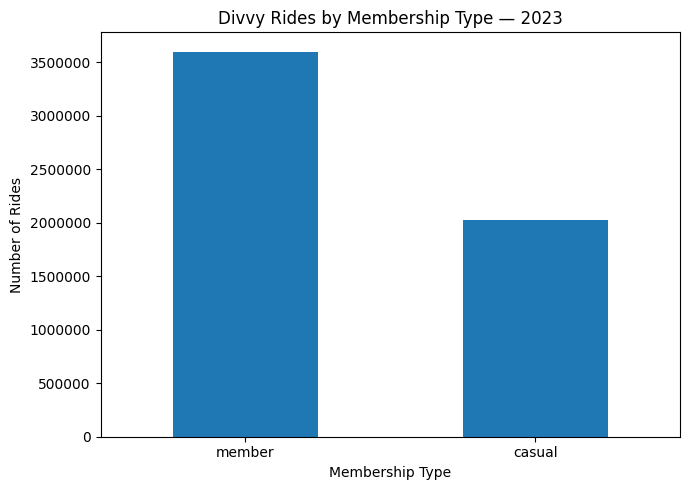

In [14]:
plt.figure(figsize=(7, 5))

member_casual_counts.plot(kind="bar")

plt.title("Divvy Rides by Membership Type — 2023")
plt.xlabel("Membership Type")
plt.ylabel("Number of Rides")

plt.xticks(rotation=0)
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

#### Observation

- Member rides made up nearly two-thirds of all Divvy trips during 2023.
- Approximately 3.60 million rides were associated with members compared with 2.03 million casual rides.
- This indicates that Divvy activity during the year was primarily driven by member rides.

### 3.3 Bike Type Distribution

- The distribution of rides across the available Divvy bike types is examined to identify which bike types were used most frequently during 2023.

In [15]:
bike_type_summary = pd.DataFrame({
    "ride_count": bike_type_counts,
    "percentage": bike_type_share
})

bike_type_summary

,ride_count,percentage
rideable_type,,
electric_bike,2900154,51.551667
classic_bike,2650236,47.109252
docked_bike,75333,1.339081


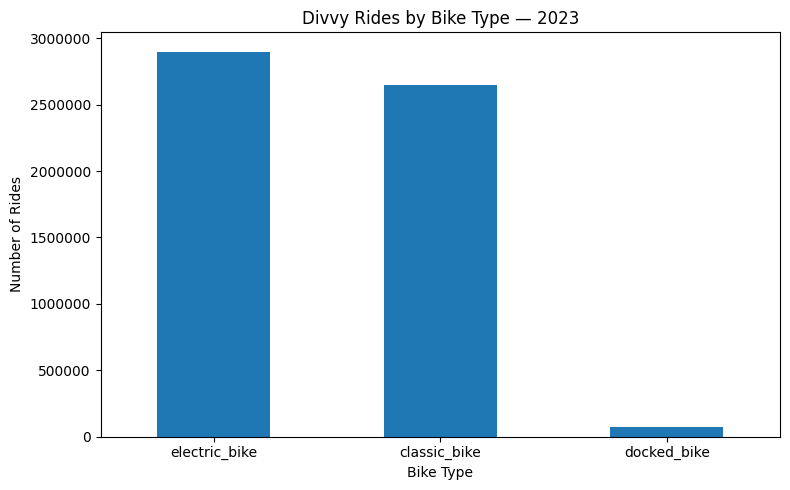

In [16]:
plt.figure(figsize=(8, 5))

bike_type_counts.plot(kind="bar")

plt.title("Divvy Rides by Bike Type — 2023")
plt.xlabel("Bike Type")
plt.ylabel("Number of Rides")

plt.xticks(rotation=0)
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

#### Observation

- Electric bikes were the most commonly used bike type, representing 51.55% of all rides.
- Classic bikes accounted for a very similar share at 47.11%.
- Docked bikes represented only 1.34% of rides and therefore formed a very small part of overall Divvy activity.
- Electric and classic bikes together accounted for almost all rides in the dataset.

### 3.4 Ride Duration Overview

- Average ride duration is calculated to provide an overall indication of trip length during 2023.

In [17]:
duration_summary = df["ride_duration_min"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

duration_summary

count    5.625723e+06
mean     1.485034e+01
std      2.147356e+01
min      1.666667e-02
25%      5.566667e+00
50%      9.666667e+00
75%      1.703333e+01
90%      2.916667e+01
95%      4.101667e+01
max      7.194333e+02
Name: ride_duration_min, dtype: float64

In [18]:
print(f"Average ride duration: {average_ride_duration:.2f} minutes")

Average ride duration: 14.85 minutes


#### Observation

- The average Divvy trip lasted approximately 14.85 minutes during 2023.
- Ride-duration differences between membership types, bike types, and other conditions will be examined later in the analysis.

### 3.5 Weekday vs Weekend Overview

- Rides are compared between weekdays and weekends to provide an initial indication of whether Divvy usage is concentrated more strongly during the working week or on weekends.

In [19]:
weekday_weekend_summary = pd.DataFrame({
    "period": ["Weekday", "Weekend"],
    "ride_count": [weekday_rides, weekend_rides],
    "percentage": [weekday_percentage, weekend_percentage]
})

weekday_weekend_summary

,period,ride_count,percentage
0,Weekday,4025885,71.562091
1,Weekend,1599838,28.437909


In [20]:
average_rides_by_day_type = df.groupby(["is_weekend","start_date"])["rideable_type"].count().groupby(["is_weekend"]).mean()
average_rides_by_day_type[1]

print(
    f"Average rides per weekday: "
    f"{average_rides_by_day_type[0]:,.0f}"
)

print(
    f"Average rides per weekend day: "
    f"{average_rides_by_day_type[1]:,.0f}"
)

Average rides per weekday: 15,484
Average rides per weekend day: 15,237


#### Observation

- Weekday rides represented 71.56% of total annual rides, compared with 28.44% for weekends.
- This difference is largely explained by the fact that there are five weekdays and only two weekend days in a typical week.
- When ride activity is compared on a per-day basis, the difference is much smaller.
- Divvy recorded an average of approximately 15,484 rides per weekday and 15,237 rides per weekend day.
- Therefore, overall daily ride volume was relatively similar between weekdays and weekends during 2023.

### 3.6 Overview Summary

- The overall analysis shows that Divvy recorded more than 5.6 million cleaned rides during 2023.

- Key findings include:

    - Member rides represented 64% of all trips, compared with 36% for casual rides.
    - Electric bikes were the most frequently used bike type at 51.55%, closely followed by classic bikes at 47.11%.
    - Docked bikes accounted for only 1.34% of rides.
    - The average ride duration was approximately 14.85 minutes.
    - Although 71.56% of annual rides occurred on weekdays, average daily ridership was very similar between weekdays and weekends.

- The next section examines how ridership changes across the year, days of the week, and hours of the day.

## 4. Temporal Usage Patterns

- This section examines how Divvy ridership changes over time.

- The analysis investigates monthly and seasonal trends, differences between days of the week, hourly demand patterns, and how usage varies between weekdays and weekends.

- The main questions are:

    - How does ridership change throughout the year?
    - Which months and seasons have the highest demand?
    - Which days of the week have the highest ride activity?
    - At what hours of the day is Divvy used most frequently?
    - Do weekday and weekend hourly patterns differ?
    - Which combinations of day and hour experience the highest demand?

### 4.1 Monthly Ridership

In [21]:
monthly_rides = (df.groupby(["month", "month_name"]).size().reset_index(name="ride_count").sort_values("month"))

monthly_rides

,month,month_name,ride_count
0,1,January,186447
1,2,February,186728
2,3,March,252759
3,4,April,416972
4,5,May,593869
5,6,June,708710
6,7,July,755189
7,8,August,759744
8,9,September,656835
9,10,October,529676


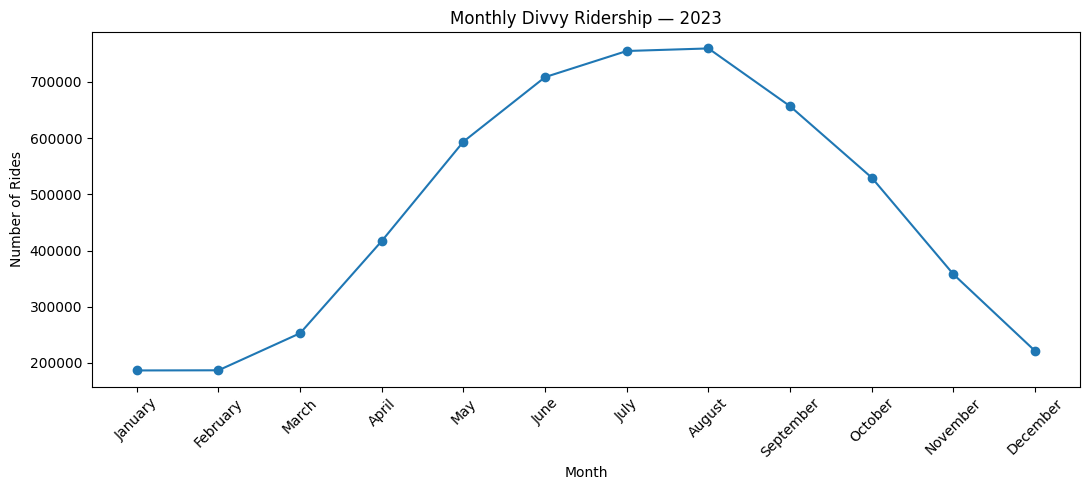

In [22]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_rides["month_name"],
    monthly_rides["ride_count"],
    marker="o"
)

plt.title("Monthly Divvy Ridership — 2023")
plt.xlabel("Month")
plt.ylabel("Number of Rides")

plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

In [23]:
highest_month = monthly_rides.loc[monthly_rides["ride_count"].idxmax()]
least_month = monthly_rides.loc[monthly_rides["ride_count"].idxmin()]

print(f"Busiest month is {highest_month['month_name']} : {highest_month['ride_count']:,} rides")
print(f"Quietest month is {least_month['month_name']} : {least_month['ride_count']:,} rides")

Busiest month is August : 759,744 rides
Quietest month is January : 186,447 rides


#### Observation

- August recorded the highest ridership during 2023, with 759,744 rides.
- January recorded the lowest ridership, with 186,447 rides.
- This indicates a substantial difference in Divvy activity between the highest- and lowest-demand months.
- The seasonal analysis in the following section will examine whether this pattern extends beyond individual months.

### 4.2 Seasonal Ridership

- Ridership is compared across seasons to determine whether the monthly demand pattern reflects broader seasonal differences in Divvy usage.

In [24]:
df.columns

Index(['rideable_type', 'started_at', 'ended_at', 'start_station_name',
       'start_station_id', 'end_station_name', 'end_station_id', 'start_lat',
       'start_lng', 'end_lat', 'end_lng', 'member_casual', 'ride_duration_min',
       'start_date', 'start_hour', 'day_of_week', 'is_weekend', 'month',
       'month_name', 'season', 'temperature_mean_c', 'temperature_min_c',
       'temperature_max_c', 'precipitation_mm', 'rain_mm', 'snowfall_cm',
       'wind_speed_max_kmh'],
      dtype='object')

In [25]:
season_order = ["Winter", "Spring", "Summer", "Fall"]
seasonal_rides = df.groupby("season").size().reindex(season_order).reset_index()
seasonal_rides.columns = ["season", "ride_count"]
percentage = (seasonal_rides["ride_count"] / len(df)) * 100
seasonal_rides["percentage"] = percentage
seasonal_rides

,season,ride_count,percentage
0,Winter,594303,10.564029
1,Spring,1263600,22.461113
2,Summer,2223643,39.526351
3,Fall,1544177,27.448508


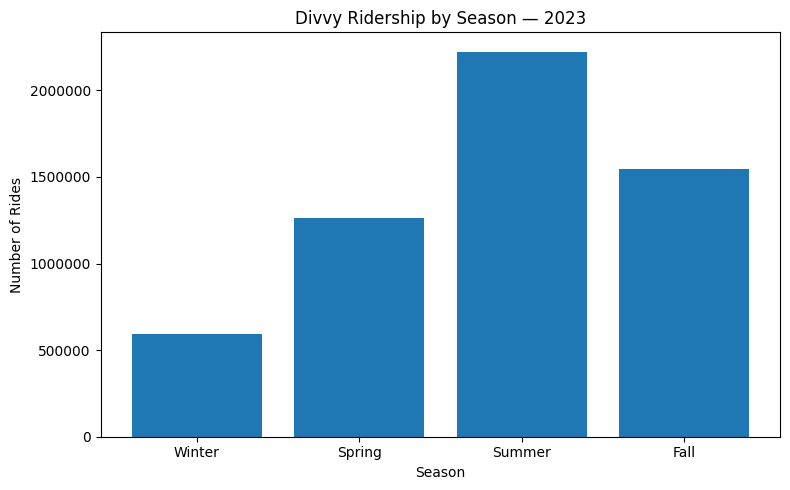

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    seasonal_rides["season"],
    seasonal_rides["ride_count"]
)

plt.title("Divvy Ridership by Season — 2023")
plt.xlabel("Season")
plt.ylabel("Number of Rides")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.tight_layout()
plt.show()

#### Observation

- Summer recorded the highest ridership, accounting for 39.53% of all Divvy rides during 2023.
- Fall followed with 27.45%, while spring represented 22.46%.
- Winter had the lowest level of activity, accounting for only 10.56% of annual rides.
- Summer recorded approximately 3.7 times as many rides as winter, showing a strong seasonal pattern in Divvy usage.

### 4.3 Day-of-Week Ridership

- Ride activity is compared across the days of the week to identify which days experience the highest and lowest demand.

In [27]:
day_order = [ "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_rides = df.groupby("day_of_week").size().reindex(day_order).reset_index()
day_rides.columns = ["day_of_week", "ride_count"]
percentage = (day_rides["ride_count"] / len(df)) * 100
day_rides["percentage"] = percentage
day_rides

,day_of_week,ride_count,percentage
0,Monday,717418,12.752459
1,Tuesday,809914,14.396621
2,Wednesday,822571,14.621605
3,Thursday,846125,15.040289
4,Friday,829857,14.751117
5,Saturday,868227,15.433163
6,Sunday,731611,13.004746


In [28]:
highest_day = day_rides.loc[day_rides["ride_count"].idxmax()]
least_day = day_rides.loc[day_rides["ride_count"].idxmin()]

print(f"Busiest day is {highest_day['day_of_week']} : {highest_day['ride_count']:,} rides")
print(f"Quietest day is {least_day['day_of_week']} : {least_day['ride_count']:,} rides")

Busiest day is Saturday : 868,227 rides
Quietest day is Monday : 717,418 rides


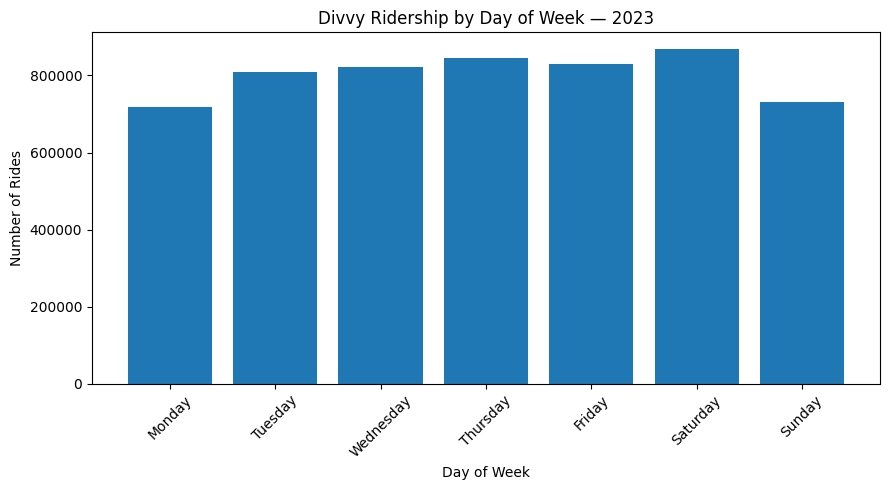

In [29]:
plt.figure(figsize=(9, 5))

plt.bar(
    day_rides["day_of_week"],
    day_rides["ride_count"]
)

plt.title("Divvy Ridership by Day of Week — 2023")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")

plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

#### Observation

- Saturday recorded the highest number of rides, with 868,227 trips, representing 15.43% of annual ridership.
- Monday recorded the lowest number of rides, with 717,418 trips, representing 12.75%.
- Ridership was relatively evenly distributed across the week, although Saturday stood out as the busiest individual day.

### 4.4 Hourly Ridership

- Ride activity is examined by trip start hour to identify the times of day when Divvy demand is highest.

In [30]:
hourly_rides = (df.groupby("start_hour").size().reset_index(name="ride_count"))

hourly_rides

,start_hour,ride_count
0,0,71134
1,1,44217
2,2,26225
3,3,15594
4,4,14525
5,5,44944
6,6,133425
7,7,243954
8,8,310161
9,9,231315


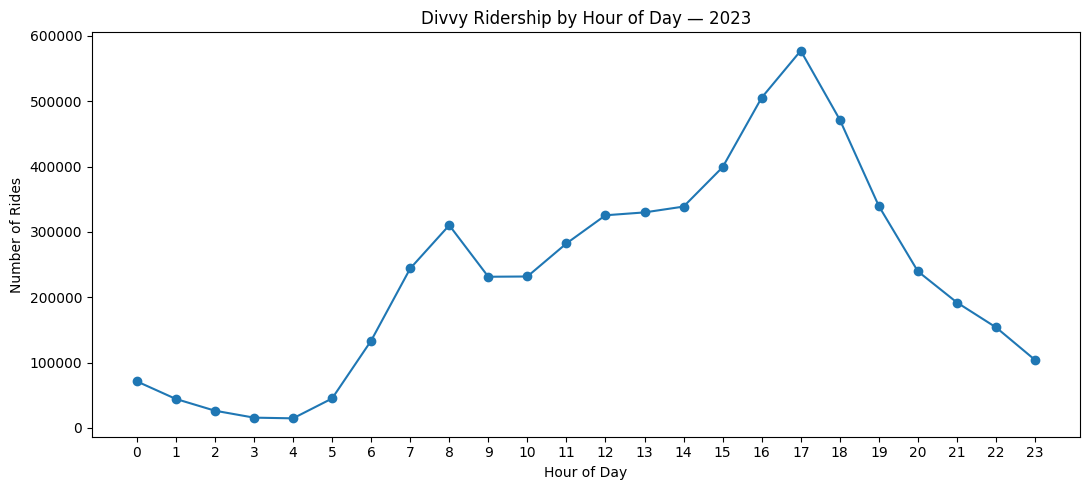

In [31]:
plt.figure(figsize=(11, 5))

plt.plot(
    hourly_rides["start_hour"],
    hourly_rides["ride_count"],
    marker="o"
)

plt.title("Divvy Ridership by Hour of Day — 2023")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")

plt.xticks(range(24))
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

In [32]:
peak_hour = hourly_rides.loc[hourly_rides["ride_count"].idxmax()]
lowest_hour = hourly_rides.loc[hourly_rides["ride_count"].idxmin()]

print(f"Peak hour: {int(peak_hour['start_hour'])}:00 with {int(peak_hour['ride_count']):,} rides")
print(f"Lowest-demand hour: {int(lowest_hour['start_hour'])}:00 with {int(lowest_hour['ride_count']):,} rides")

Peak hour: 17:00 with 577,383 rides
Lowest-demand hour: 4:00 with 14,525 rides


#### Observation

- Ridership varied substantially throughout the day.
- The highest overall ride volume occurred at 17:00, with 577,383 rides during the year.
- The lowest ride volume occurred at 04:00, with only 14,525 rides.
- A clear morning increase is visible around 07:00–08:00, followed by a larger afternoon and evening peak between approximately 16:00 and 18:00.
- The strong 17:00 peak suggests that commuting activity contributes substantially to Divvy demand.

### 4.5 Weekday vs Weekend Hourly Patterns

- Hourly ridership patterns are compared between weekdays and weekends.

- Average rides per hour are used rather than total counts because the year contains more weekdays than weekend days.

In [33]:
df.columns

Index(['rideable_type', 'started_at', 'ended_at', 'start_station_name',
       'start_station_id', 'end_station_name', 'end_station_id', 'start_lat',
       'start_lng', 'end_lat', 'end_lng', 'member_casual', 'ride_duration_min',
       'start_date', 'start_hour', 'day_of_week', 'is_weekend', 'month',
       'month_name', 'season', 'temperature_mean_c', 'temperature_min_c',
       'temperature_max_c', 'precipitation_mm', 'rain_mm', 'snowfall_cm',
       'wind_speed_max_kmh'],
      dtype='object')

In [34]:
daily_hourly_rides = df.groupby(["start_date", "day_of_week", "is_weekend", "start_hour"]).size().reset_index(name = "ride_count")
daily_hourly_rides.head()

,start_date,day_of_week,is_weekend,start_hour,ride_count
0,2023-01-01,Sunday,1,0,253
1,2023-01-01,Sunday,1,1,336
2,2023-01-01,Sunday,1,2,307
3,2023-01-01,Sunday,1,3,47
4,2023-01-01,Sunday,1,4,35


In [35]:
average_daily_hourly_rides = daily_hourly_rides.groupby(["is_weekend", "start_hour"])["ride_count"].mean().reset_index(name = "average_rides")
average_daily_hourly_rides.head(60)

,is_weekend,start_hour,average_rides
0,0,0,123.792308
1,0,1,66.796154
2,0,2,38.796154
3,0,3,27.111538
4,0,4,35.500000
5,0,5,147.034615
6,0,6,457.615385
7,0,7,841.692308
8,0,8,1023.576923
9,0,9,619.603846


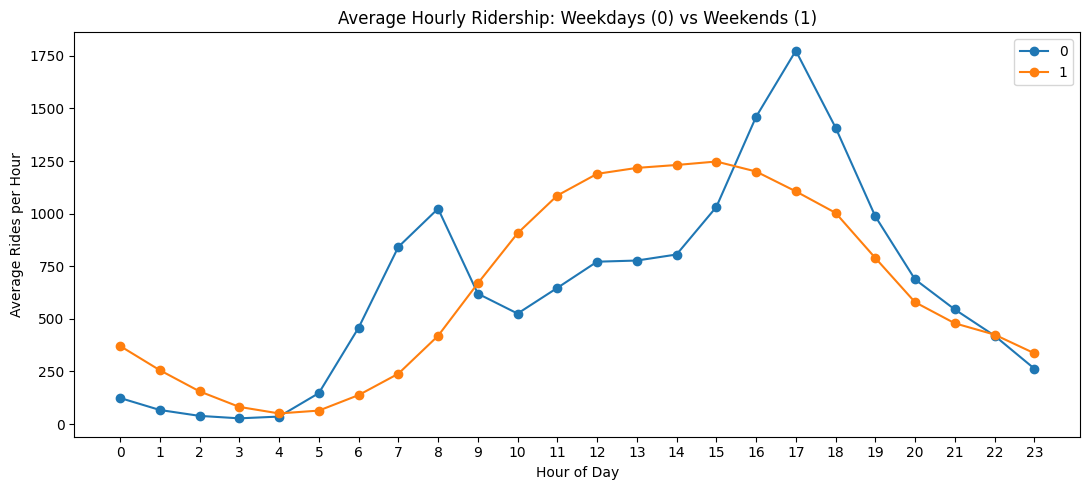

In [36]:
plt.figure(figsize=(11, 5))

for type in [0, 1]:

    data = average_daily_hourly_rides[
        average_daily_hourly_rides["is_weekend"] == type
    ]

    plt.plot(
        data["start_hour"],
        data["average_rides"],
        marker="o",
        label=type
    )

plt.title("Average Hourly Ridership: Weekdays (0) vs Weekends (1)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rides per Hour")

plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
weekday_hourly = average_daily_hourly_rides[average_daily_hourly_rides["is_weekend"] == 0]
weekend_hourly = average_daily_hourly_rides[average_daily_hourly_rides["is_weekend"] == 1]

weekday_peak = weekday_hourly.loc[weekday_hourly["average_rides"].idxmax()]
weekend_peak = weekend_hourly.loc[weekend_hourly["average_rides"].idxmax()]

print(f"Weekday peak: {int(weekday_peak['start_hour'])}:00 with an average of {weekday_peak['average_rides']} rides")
print(f"Weekend peak: {int(weekend_peak['start_hour'])}:00 with an average of {weekend_peak['average_rides']} rides")

Weekday peak: 17:00 with an average of 1774.126923076923 rides
Weekend peak: 15:00 with an average of 1247.5523809523809 rides


#### Observation

- Weekday and weekend ridership follow noticeably different hourly patterns.
- On weekdays, demand shows a pronounced morning peak around 08:00 and a substantially larger evening peak around 17:00.
- The weekday peak occurs at 17:00, with an average of approximately 1,774 rides per hour.
- Weekend activity increases more gradually during the morning and remains relatively high through the afternoon.
- Weekend demand reaches its highest level at 15:00, with an average of approximately 1,248 rides.
- These differences suggest that weekday Divvy usage is more strongly associated with commuting periods, while weekend usage is more concentrated around daytime and afternoon activity.

### 4.6 Day-of-Week and Hourly Demand

- Day of the week and trip start hour are analyzed together to identify when Divvy demand is concentrated during a typical week.

In [38]:
daily_hourly_rides

,start_date,day_of_week,is_weekend,start_hour,ride_count
0,2023-01-01,Sunday,1,0,253
1,2023-01-01,Sunday,1,1,336
2,2023-01-01,Sunday,1,2,307
3,2023-01-01,Sunday,1,3,47
4,2023-01-01,Sunday,1,4,35
...,...,...,...,...,...
8754,2023-12-31,Sunday,1,19,171
8755,2023-12-31,Sunday,1,20,139
8756,2023-12-31,Sunday,1,21,115
8757,2023-12-31,Sunday,1,22,120


In [39]:
average_day_hour = (daily_hourly_rides.groupby(["day_of_week", "start_hour"])["ride_count"].mean().reset_index())
average_day_hour.columns = ["day_of_week", "start_hour", "average_rides"]
average_day_hour

,day_of_week,start_hour,average_rides
0,Friday,0,172.538462
1,Friday,1,100.096154
2,Friday,2,52.673077
3,Friday,3,35.788462
4,Friday,4,38.423077
...,...,...,...
163,Wednesday,19,999.634615
164,Wednesday,20,702.903846
165,Wednesday,21,580.403846
166,Wednesday,22,412.115385


In [40]:
day_hour_matrix = (average_day_hour.pivot(index="day_of_week", columns="start_hour", values="average_rides").reindex(day_order))

day_hour_matrix

start_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,120.500000,65.076923,40.134615,30.038462,35.557692,131.846154,394.115385,699.903846,863.903846,554.942308,...,769.615385,948.673077,1290.596154,1569.557692,1252.307692,895.980769,621.038462,439.192308,289.461538,165.846154
Tuesday,95.923077,50.615385,31.596154,22.365385,35.076923,159.173077,495.403846,952.115385,1159.730769,636.365385,...,731.769231,981.500000,1524.807692,1894.365385,1453.423077,1000.365385,694.038462,549.769231,381.750000,198.038462
Wednesday,107.211538,56.403846,32.115385,23.019231,34.673077,161.846154,482.538462,956.730769,1168.826923,647.711538,...,760.211538,995.923077,1527.769231,1920.500000,1442.942308,999.634615,702.903846,580.403846,412.115385,231.826923
Thursday,122.788462,61.788462,37.461538,24.346154,33.769231,149.096154,462.865385,898.980769,1118.211538,674.615385,...,776.692308,1025.884615,1492.807692,1900.269231,1547.596154,1073.769231,740.134615,608.557692,517.846154,299.230769
Friday,172.538462,100.096154,52.673077,35.788462,38.423077,133.211538,453.153846,700.730769,807.211538,584.384615,...,990.173077,1204.423077,1462.596154,1585.942308,1348.730769,964.923077,678.653846,544.942308,498.250000,422.903846
Saturday,346.134615,257.250000,143.153846,78.038462,42.038462,64.346154,149.115385,268.192308,493.788462,750.076923,...,1306.538462,1310.326923,1283.807692,1219.634615,1121.711538,898.269231,660.038462,569.769231,557.423077,484.519231
Sunday,395.264151,254.207547,167.192308,84.660377,58.660377,63.566038,126.245283,210.716981,346.301887,588.943396,...,1157.056604,1185.962264,1117.905660,994.132075,887.792453,682.226415,499.452830,389.415094,295.169811,191.132075


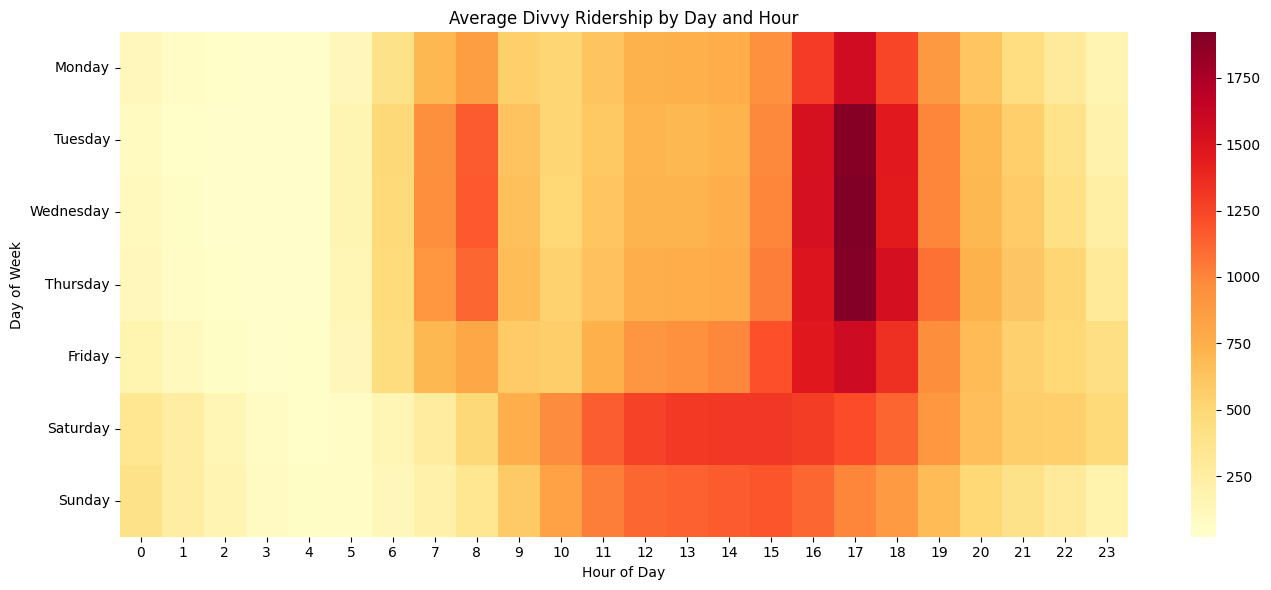

In [41]:
plt.figure(figsize=(14, 6))

sns.heatmap(day_hour_matrix, cmap="YlOrRd")

plt.title("Average Divvy Ridership by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

In [42]:
highest_day_hour = average_day_hour.loc[average_day_hour["average_rides"].idxmax()]

print(
    f"Highest average demand is {highest_day_hour['day_of_week']} at {int(highest_day_hour['start_hour'])}:00 ",
    f"with an average of {highest_day_hour['average_rides']:,.0f} rides")

Highest average demand is Wednesday at 17:00  with an average of 1,920 rides


#### Observation

- Combining day of the week with hour of the day reveals more detailed demand patterns than analyzing either variable separately.
- The highest average hourly demand occurs on Wednesday at 17:00, with approximately 1,920 rides.
- Weekday demand is strongly concentrated around the late-afternoon period, particularly around 17:00.
- Weekend demand is more broadly distributed across the late morning and afternoon.
- The day-hour analysis reinforces the difference between weekday peak-period usage and the more gradual daytime pattern observed on weekends.

### 4.7 Analysis Summary


- Key findings include:

    - August was the busiest month, with 759,744 rides, while January had the lowest ridership with 186,447 rides.
    - Summer accounted for 39.53% of annual rides, compared with only 10.56% during winter.
    - Saturday was the busiest individual day of the week, while Monday recorded the lowest total ridership.
    - Overall demand peaked at 17:00.
    - Weekday ridership displayed distinct morning and evening peaks, with the strongest demand occurring around the evening commuting period.
    - Weekend ridership followed a different pattern, increasing gradually through the morning and reaching its highest level during the afternoon.
    - The highest average day-hour demand occurred on Wednesday at 17:00.

- These results show that Divvy demand is influenced by both seasonal and weekly usage patterns. The following section examines how these patterns differ between member and casual rides.

## 5. Member vs Casual Ride Analysis

- Member and casual rides are compared to understand whether the two membership categories display different usage patterns.

- The analysis examines:

    - Average ride duration
    - Monthly ridership trends
    - Day-of-week behavior
    - Hourly demand patterns
    - Weekday and weekend usage
    - Seasonal differences

- These comparisons help determine whether member and casual rides reflect different patterns of Divvy usage.

### 5.1 Average Ride Duration by Membership Type

In [43]:
duration_by_membership = df.groupby("member_casual")["ride_duration_min"].mean().reset_index()
duration_by_membership

,member_casual,ride_duration_min
0,casual,19.841864
1,member,12.043046


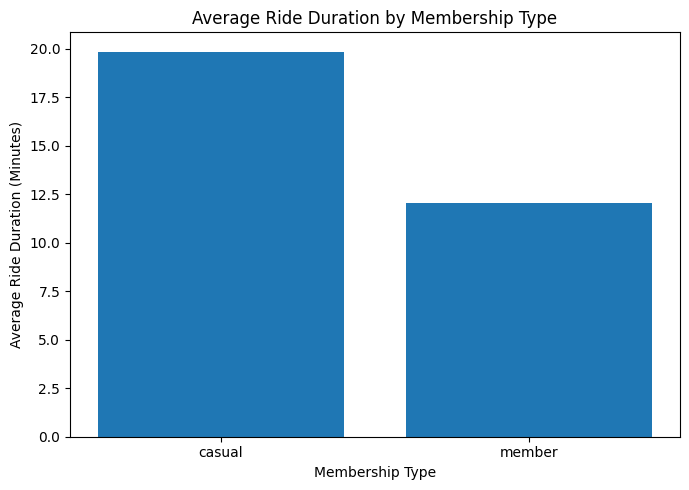

In [44]:
plt.figure(figsize=(7, 5))

plt.bar(
    duration_by_membership["member_casual"],
    duration_by_membership["ride_duration_min"]
)

plt.title("Average Ride Duration by Membership Type")
plt.xlabel("Membership Type")
plt.ylabel("Average Ride Duration (Minutes)")

plt.tight_layout()
plt.show()

#### Observation

- Casual rides lasted considerably longer on average than member rides.
- The average casual ride lasted approximately 19.84 minutes, compared with 12.04 minutes for member rides.
- This means casual rides were roughly 65% longer on average than member rides.

### 5.2 Monthly Member vs Casual Ridership

- Monthly ridership is compared between member and casual rides to determine whether seasonal demand patterns differ between the two membership categories.

In [45]:
monthly_membership = df.groupby(["month", "month_name", "member_casual"]).size().reset_index(name="ride_count").sort_values("month")

monthly_membership

,month,month_name,member_casual,ride_count
0,1,January,casual,39278
1,1,January,member,147169
2,2,February,casual,42250
3,2,February,member,144478
4,3,March,casual,60966
5,3,March,member,191793
6,4,April,casual,144420
7,4,April,member,272552
8,5,May,casual,230075
9,5,May,member,363794


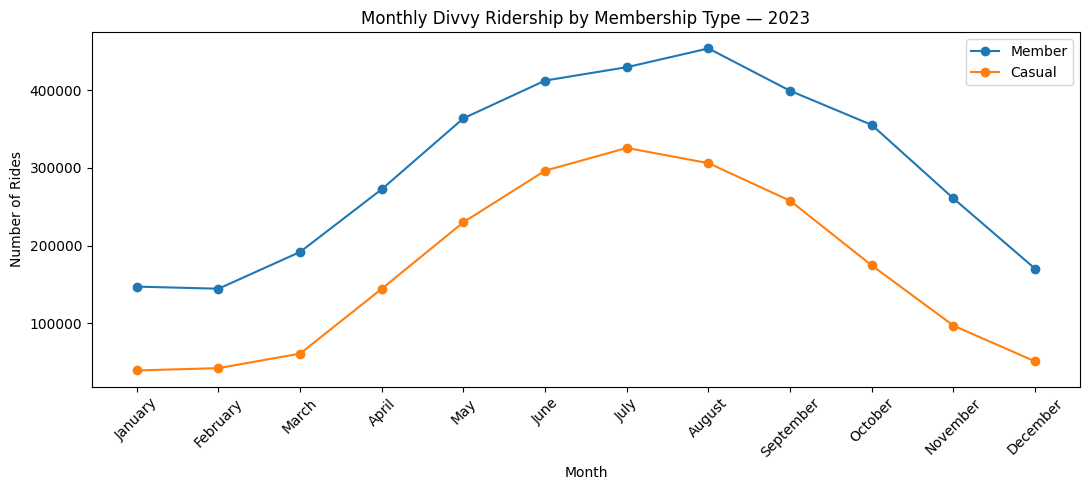

In [46]:
plt.figure(figsize=(11, 5))

for rider_type in ["member", "casual"]:

    data = monthly_membership[monthly_membership["member_casual"] == rider_type]

    plt.plot(data["month_name"],
            data["ride_count"],
            marker="o",
            label=rider_type.capitalize())

plt.title("Monthly Divvy Ridership by Membership Type — 2023")
plt.xlabel("Month")
plt.ylabel("Number of Rides")

plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")

plt.legend()

plt.tight_layout()
plt.show()

#### Observation

- Member rides exceeded casual rides in every month of 2023.
- Both membership categories showed a strong seasonal increase from winter into summer, followed by a decline toward the end of the year.
- Casual ridership showed a particularly strong seasonal pattern, increasing from 39,278 rides in January to 325,640 rides in July.
- Member ridership reached its highest monthly level in August, with 453,693 rides.
- Casual ridership peaked one month earlier, in July, with 325,640 rides.
- The summer increase was therefore present for both groups but was especially pronounced among casual rides.

### 5.3 Day-of-Week Patterns by Membership Type

- Ridership by day of the week is compared between member and casual rides to identify differences in weekly usage patterns.

In [47]:
day_membership = (df.groupby(["day_of_week", "member_casual"]).size().reset_index(name="ride_count"))
day_membership["day_of_week"] = pd.Categorical(day_membership["day_of_week"], categories=day_order, ordered=True)
day_membership =day_membership.sort_values("day_of_week").reset_index(drop = True)

day_membership

,day_of_week,member_casual,ride_count
0,Monday,casual,230963
1,Monday,member,486455
2,Tuesday,casual,242328
3,Tuesday,member,567586
4,Wednesday,casual,245217
5,Wednesday,member,577354
6,Thursday,casual,266327
7,Thursday,member,579798
8,Friday,casual,306993
9,Friday,member,522864


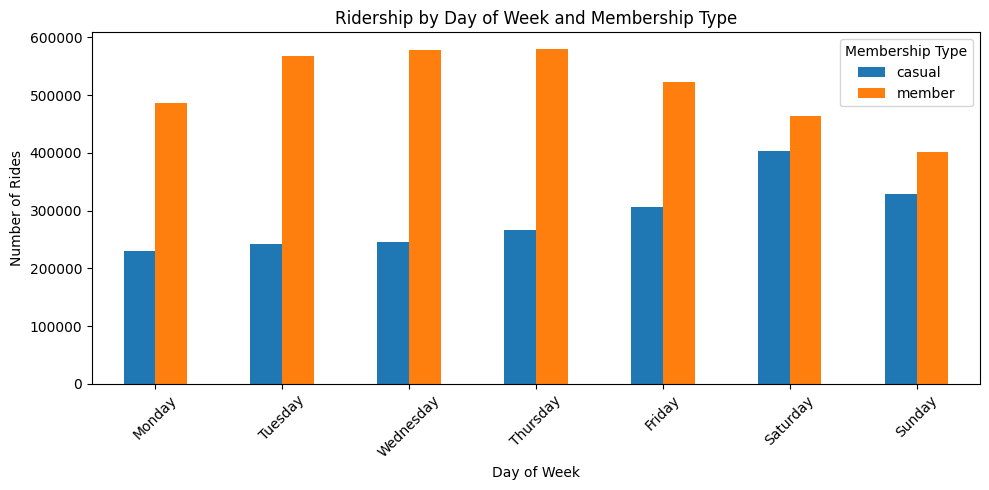

In [48]:
day_membership_pivot = day_membership.pivot(index="day_of_week", columns="member_casual", values="ride_count")

day_membership_pivot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Ridership by Day of Week and Membership Type")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")

plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")

plt.legend(title="Membership Type")

plt.tight_layout()
plt.show()

#### Observation

- Member rides outnumbered casual rides on every day of the week.
- Member activity was strongest on Thursday, with 579,798 rides.
- Casual activity was highest on Saturday, with 403,609 rides.
- Casual rides represented a much larger share of total activity on weekends than during the middle of the working week.
- On Saturday, casual rides represented approximately 46.5% of all rides, compared with around 30% on Tuesday and Wednesday.
- This indicates a clear difference in weekly usage patterns between member and casual rides.

### 5.4 Hourly Patterns by Membership Type

- Hourly ridership is compared between member and casual rides to determine whether the two membership categories use Divvy at different times of day.

In [49]:
hourly_membership = (df.groupby(["start_hour", "member_casual"]).size().reset_index(name="ride_count"))

hourly_membership

,start_hour,member_casual,ride_count
0,0,casual,36213
1,0,member,34921
2,1,casual,23445
3,1,member,20772
4,2,casual,14168
5,2,member,12057
6,3,casual,7772
7,3,member,7822
8,4,casual,5863
9,4,member,8662


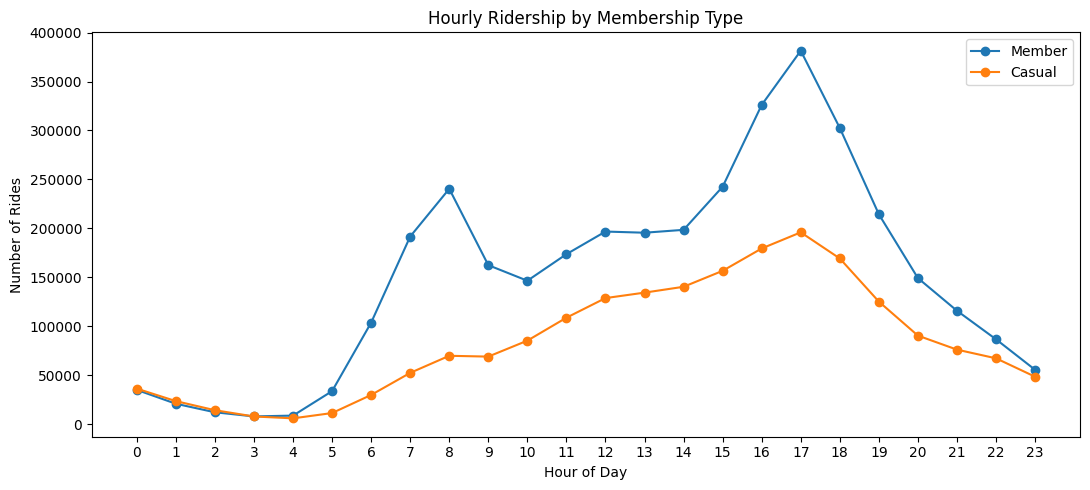

In [50]:
plt.figure(figsize=(11, 5))

for rider_type in ["member", "casual"]:

    data = hourly_membership[hourly_membership["member_casual"] == rider_type]

    plt.plot(
        data["start_hour"],
        data["ride_count"],
        marker="o",
        label=rider_type.capitalize()
    )

plt.title("Hourly Ridership by Membership Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")

plt.xticks(range(24))
plt.ticklabel_format(style="plain", axis="y")

plt.legend()

plt.tight_layout()
plt.show()

In [51]:
member_hourly = hourly_membership[hourly_membership["member_casual"] == "member"]
casual_hourly = hourly_membership[hourly_membership["member_casual"] == "casual"]

member_peak = member_hourly.loc[member_hourly["ride_count"].idxmax()]
casual_peak = casual_hourly.loc[casual_hourly["ride_count"].idxmax()]

print(f"Member peak hour: {int(member_peak['start_hour'])}:00 with {int(member_peak['ride_count']):,} rides")
print(f"Casual peak hour: {int(casual_peak['start_hour'])}:00 with {int(casual_peak['ride_count']):,} rides")

Member peak hour: 17:00 with 381,477 rides
Casual peak hour: 17:00 with 195,906 rides


#### Observation

- Both member and casual rides reached their highest total volume at 17:00.
- Member rides peaked at 381,477 trips, while casual rides peaked at 195,906.
- Member ridership shows a particularly strong increase during the morning and evening commuting periods.
- Casual ridership increases more gradually through the day and is more concentrated during the afternoon and early evening.
- Although both groups share the same overall peak hour, their hourly usage patterns differ substantially.

### 5.5 Weekday vs Weekend Behavior by Membership Type

- Member and casual rides are compared between weekdays and weekends to examine whether membership composition changes across the week.

In [52]:
period_membership = (df.groupby(["is_weekend", "member_casual"]).size().reset_index(name="ride_count"))
period_membership["period"] = (period_membership["is_weekend"].map({0: "Weekday",1: "Weekend"}))

period_membership

,is_weekend,member_casual,ride_count,period
0,0,casual,1291828,Weekday
1,0,member,2734057,Weekday
2,1,casual,733231,Weekend
3,1,member,866607,Weekend


In [53]:
period_membership["percentage"] = (
    period_membership["ride_count"]
    / period_membership.groupby("period")["ride_count"].transform("sum")
    * 100
)

period_membership

,is_weekend,member_casual,ride_count,period,percentage
0,0,casual,1291828,Weekday,32.088050
1,0,member,2734057,Weekday,67.911950
2,1,casual,733231,Weekend,45.831578
3,1,member,866607,Weekend,54.168422


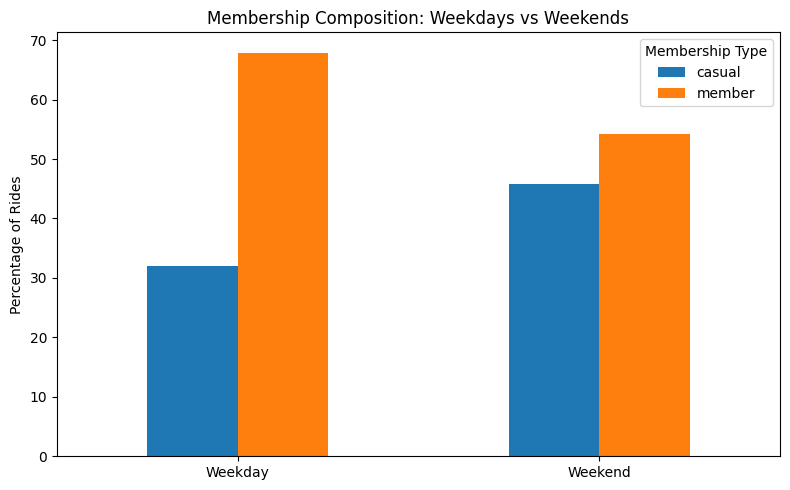

In [54]:
period_membership_pivot = (
    period_membership
    .pivot(
        index="period",
        columns="member_casual",
        values="percentage"
    )
    .reindex(["Weekday", "Weekend"])
)

period_membership_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Membership Composition: Weekdays vs Weekends")
plt.xlabel("")
plt.ylabel("Percentage of Rides")

plt.xticks(rotation=0)

plt.legend(title="Membership Type")

plt.tight_layout()
plt.show()

#### Observation

- Member rides dominated both weekdays and weekends, but the membership composition changed substantially.
- Members represented approximately 67.91% of weekday rides, while casual rides represented 32.09%.
- On weekends, the casual share increased to 45.83%, while the member share declined to 54.17%.
- Casual rides therefore made up a substantially larger proportion of Divvy activity during weekends.
- This supports the earlier finding that casual usage is more strongly associated with weekend activity.

### 5.6 Seasonal Patterns by Membership Type

- Seasonal ridership is compared between member and casual rides to determine whether the two categories respond differently to seasonal changes.

In [55]:
season_membership = (df.groupby(["season", "member_casual"]).size().reset_index(name="ride_count"))
season_membership["season"] = pd.Categorical(season_membership["season"], categories = season_order, ordered = True)
season_membership = season_membership.sort_values("season")

season_membership

,season,member_casual,ride_count
6,Winter,casual,132442
7,Winter,member,461861
2,Spring,casual,435461
3,Spring,member,828139
4,Summer,casual,928057
5,Summer,member,1295586
0,Fall,casual,529099
1,Fall,member,1015078


In [56]:
season_membership["percentage"] = (season_membership["ride_count"]/ season_membership.groupby("season")["ride_count"].transform("sum") * 100)

season_membership

C:\Users\ramya\AppData\Local\Temp\ipykernel_39728\2547776787.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_membership["percentage"] = (season_membership["ride_count"]/ season_membership.groupby("season")["ride_count"].transform("sum") * 100)


,season,member_casual,ride_count,percentage
6,Winter,casual,132442,22.285265
7,Winter,member,461861,77.714735
2,Spring,casual,435461,34.461934
3,Spring,member,828139,65.538066
4,Summer,casual,928057,41.735881
5,Summer,member,1295586,58.264119
0,Fall,casual,529099,34.264142
1,Fall,member,1015078,65.735858


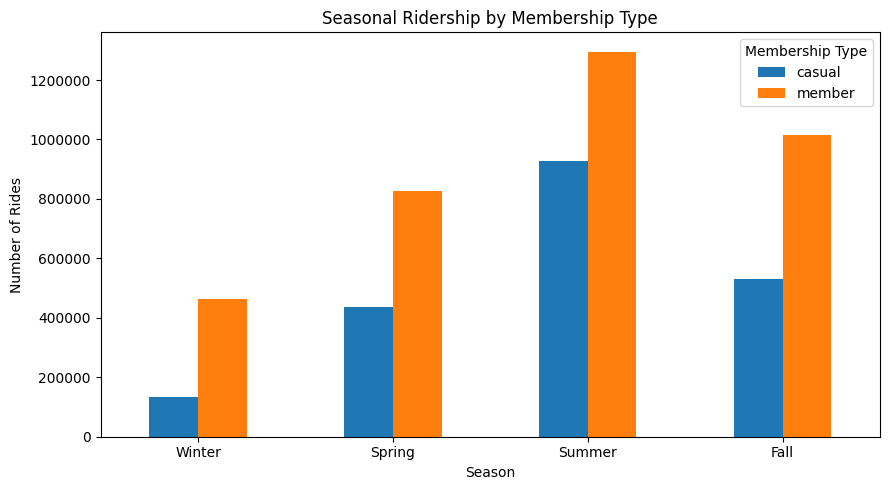

In [57]:
season_membership_pivot = (season_membership.pivot(index="season",columns="member_casual",values="ride_count"))

season_membership_pivot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Seasonal Ridership by Membership Type")
plt.xlabel("Season")
plt.ylabel("Number of Rides")

plt.xticks(rotation=0)
plt.ticklabel_format(style="plain", axis="y")

plt.legend(title="Membership Type")

plt.tight_layout()
plt.show()

#### Observation

- Member rides exceeded casual rides during every season.
- The difference between the two groups was largest during winter, when members represented approximately 77.71% of rides and casual rides only 22.29%.
- The casual share increased substantially during warmer seasons, reaching 41.74% of all summer rides.
- Summer recorded the highest ride volume for both membership categories.
- Casual ridership therefore appears substantially more seasonal than member ridership, while member activity remains comparatively stronger throughout the colder months.

### 5.7 Member vs Casual Analysis Summary

- The analysis reveals clear behavioral differences between member and casual rides.

- Key findings include:

    - Member rides represented the majority of Divvy activity throughout the year.
    - Casual rides lasted substantially longer on average, at 19.84 minutes compared with 12.04 minutes for member rides.
    - Member ridership remained higher during every month and season.
    - Casual ridership showed stronger seasonal variation and increased considerably during the summer.
    - Member rides were more dominant during weekdays, while the casual share increased substantially on weekends.
    - Member usage showed stronger morning and evening peak-period patterns, while casual usage was more concentrated during daytime and afternoon hours.
    - Although both groups reached their highest overall hourly volume at 17:00, their broader temporal patterns differed.

- These results suggest that member rides are more closely associated with regular and recurring travel patterns, while casual rides are more strongly associated with weekend, seasonal, and recreational-style usage.

## 6. Bike Type Analysis

- This section examines whether bike-type usage differs across membership types, seasons, and weekday/weekend periods, and whether ride duration varies between bike types.

- The analysis addresses the following questions:

    - Do member and casual rides show different bike-type preferences?
    - Does bike-type usage change across seasons?
    - Does bike-type usage differ between weekdays and weekends?
    - Does average ride duration differ between bike types?

### 6.1 Bike Type Normalization

The source dataset contains three `rideable_type` labels: `classic_bike`,
`electric_bike`, and `docked_bike`.

Divvy/Lyft documentation and historical platform information indicate that
`docked_bike` is a legacy label for the standard non-electric bike type rather
than a separate physical bike category.

For analysis, `docked_bike` rides are therefore grouped with `classic_bike`
rides under a normalized `bike_type` variable. The original `rideable_type`
column is retained unchanged.

In [58]:
df["bike_type"] = df["rideable_type"].replace({"docked_bike": "classic_bike"})

### 6.2 Do Member and Casual Rides Show Different Bike-Type Preferences?

In [59]:
bike_membership = df.groupby(["member_casual", "bike_type"]).size().reset_index(name = "ride_count")
bike_membership["percentage"] = bike_membership["ride_count"] / bike_membership.groupby("member_casual")['ride_count'].transform("sum")* 100
bike_membership

,member_casual,bike_type,ride_count,percentage
0,casual,classic_bike,934695,46.156433
1,casual,electric_bike,1090364,53.843567
2,member,classic_bike,1790874,49.737326
3,member,electric_bike,1809790,50.262674


#### Observation

- Bike-type usage was relatively balanced for both membership groups.
- Electric bikes represented 53.84% of casual rides, compared with 46.16% for classic bikes.
- Member rides were almost evenly divided between electric bikes (50.26%) and classic bikes (49.74%).
- Casual rides therefore showed a slightly stronger preference for electric bikes than member rides.

### 6.3 Does Bike-Type Usage Change Across Seasons?

In [60]:
bike_season = df.groupby(["bike_type", "season"]).size().reset_index(name = "ride_count")
bike_season["percentage"] = bike_season["ride_count"] / bike_season.groupby("season")['ride_count'].transform("sum") * 100
bike_season

,bike_type,season,ride_count,percentage
0,classic_bike,Fall,778711,50.428869
1,classic_bike,Spring,561722,44.454099
2,classic_bike,Summer,1100700,49.499852
3,classic_bike,Winter,284436,47.860435
4,electric_bike,Fall,765466,49.571131
5,electric_bike,Spring,701878,55.545901
6,electric_bike,Summer,1122943,50.500148
7,electric_bike,Winter,309867,52.139565


#### Observation

- Bike-type usage remained relatively balanced throughout all four seasons.
- Electric bikes had their highest share during spring, representing 55.55% of rides.
- Classic bikes slightly exceeded electric bikes during fall, representing 50.43% of rides.
- The difference between classic and electric bike shares remained fairly small across the year.

### 6.4 Does Bike-Type Usage Differ Between Weekdays and Weekends?

In [61]:
bike_period = (df.groupby(["is_weekend", "bike_type"]).size().reset_index(name="ride_count"))
bike_period["period"] = bike_period["is_weekend"].map({0: "Weekday",1: "Weekend"})
bike_period["percentage"] = bike_period["ride_count"]/ bike_period.groupby("period")["ride_count"].transform("sum")* 100

bike_period

,is_weekend,bike_type,ride_count,period,percentage
0,0,classic_bike,1920574,Weekday,47.705635
1,0,electric_bike,2105311,Weekday,52.294365
2,1,classic_bike,804995,Weekend,50.317282
3,1,electric_bike,794843,Weekend,49.682718


#### Observation

- Weekday rides were 52.29% electric and 47.71% classic.
- Weekend rides were almost evenly divided, with 49.68% electric and 50.32% classic.
- The difference between weekday and weekend bike-type composition is therefore small.

### 6.5 Does Average Ride Duration Differ Between Bike Types?

In [62]:
bike_duration = df.groupby("bike_type")["ride_duration_min"].mean().reset_index()
bike_duration.columns = ["bike_type","average_duration_min"]

bike_duration

,bike_type,average_duration_min
0,classic_bike,17.360440
1,electric_bike,12.491347


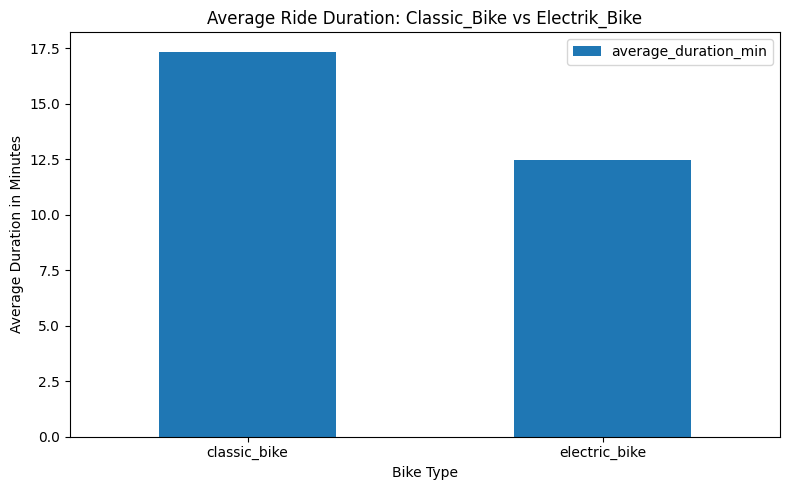

In [63]:
bike_duration.set_index("bike_type").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Ride Duration: Classic_Bike vs Electrik_Bike")
plt.xlabel("Bike Type")
plt.ylabel("Average Duration in Minutes")

plt.xticks(rotation=0)


plt.tight_layout()
plt.show()

In [64]:
bike_duration_membership = (df.groupby(["member_casual", "bike_type"])["ride_duration_min"].mean().reset_index())

bike_duration_membership

,member_casual,bike_type,ride_duration_min
0,casual,classic_bike,26.157332
1,casual,electric_bike,14.428042
2,member,classic_bike,12.769157
3,member,electric_bike,11.324525


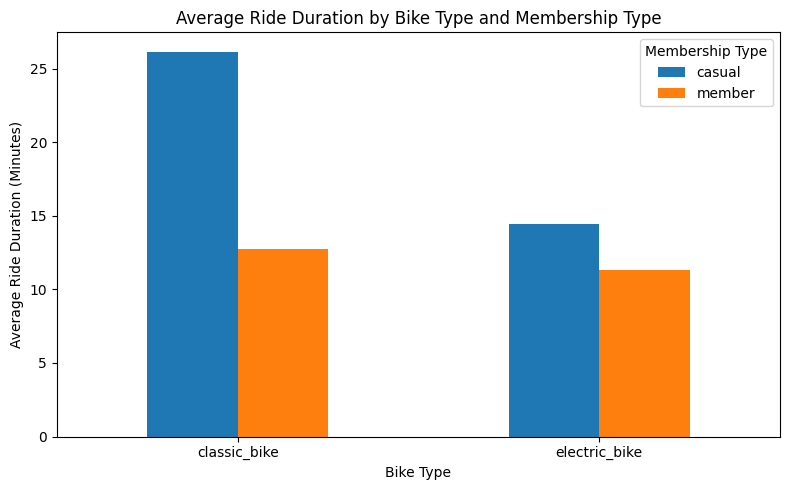

In [65]:
bike_duration_pivot = bike_duration_membership.pivot(
    index="bike_type",
    columns="member_casual",
    values="ride_duration_min"
)

bike_duration_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Ride Duration by Bike Type and Membership Type")
plt.xlabel("Bike Type")
plt.ylabel("Average Ride Duration (Minutes)")
plt.xticks(rotation=0)
plt.legend(title="Membership Type")
plt.tight_layout()
plt.show()

#### Observation

- Classic-bike rides lasted longer on average than electric-bike rides.
- Across all rides, classic-bike trips averaged approximately 17.36 minutes, compared with 12.49 minutes for electric-bike trips.
- The difference remains visible after separating member and casual rides.
- Among casual rides, classic-bike trips averaged 26.16 minutes compared with 14.43 minutes for electric-bike trips.
- Among member rides, classic-bike trips averaged 12.77 minutes compared with 11.32 minutes for electric-bike trips.
- The difference is therefore much stronger among casual rides than among member rides.

The difference in ride duration is the clearest pattern identified in this section, particularly among casual rides.

### 6.6 Bike Type Analysis Summary

- The bike-type analysis shows that classic and electric bikes were used in relatively similar proportions across most rider and time categories.

- Key findings include:

    - Casual rides showed a slightly greater preference for electric bikes than member rides, although the difference was relatively small.
    - Bike-type composition changed only moderately across seasons.
    - Weekday and weekend bike-type usage was very similar, indicating little difference in bike choice between the two periods.
    - The clearest difference appeared in ride duration: classic-bike rides averaged 17.36 minutes, compared with 12.49 minutes for electric-bike rides.

Overall, **ride duration showed the clearest difference between classic and electric bike usage**, while bike-type preferences remained relatively stable across membership groups, seasons, and weekday/weekend periods.

## 7. Weather and Ridership Analysis

- This section examines how daily weather conditions are associated with Divvy ridership.

- The processed dataset contains daily weather features that are repeated across all trips occurring on the same date. Therefore, trip-level data is aggregated to one row per day before weather relationships are examined.

- The analysis addresses the following questions:

    - How does temperature relate to daily ridership?
    - How does rain affect daily ridership?
    - How does snowfall affect daily ridership?
    - Does wind speed show a relationship with daily ridership?
    - Do member and casual rides respond differently to weather conditions?

### 7.1 Create the Daily Analysis Dataset

- Trip-level data is aggregated to one row per day so that daily ridership can be compared correctly with daily weather conditions.

In [66]:
daily_rides = df.groupby("start_date").agg({"rideable_type": "count", "ride_duration_min":"mean"}).reset_index()
daily_rides.columns = ["start_date", "ride_count", "avg_ride_duration"]

daily_rides.head()

,start_date,ride_count,avg_ride_duration
0,2023-01-01,5034,15.425222
1,2023-01-02,5393,12.474578
2,2023-01-03,5056,10.469422
3,2023-01-04,7144,10.453747
4,2023-01-05,6393,9.982721


In [67]:
daily_member_rides = df[df["member_casual"] == "member"].groupby("start_date").size().reset_index(name="member_rides")
daily_casual_rides = df[df["member_casual"] == "casual"].groupby("start_date").size().reset_index(name="casual_rides")

In [68]:
weather_columns = ["temperature_mean_c", "temperature_min_c", "temperature_max_c", "precipitation_mm", "rain_mm", "snowfall_cm", "wind_speed_max_kmh"]

daily_weather = df.groupby("start_date")[weather_columns].first().reset_index()
daily_weather

,start_date,temperature_mean_c,temperature_min_c,temperature_max_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh
0,2023-01-01,4.122917,1.20,8.50,3.300000,3.300000,0.00,17.068707
1,2023-01-02,2.052083,-0.45,4.55,0.300000,0.300000,0.00,18.075441
2,2023-01-03,7.339583,3.95,12.70,13.100001,13.100001,0.00,23.598541
3,2023-01-04,2.610417,0.15,8.80,0.000000,0.000000,0.00,23.006226
4,2023-01-05,0.152083,-0.40,0.90,1.300000,0.100000,0.91,21.313093
...,...,...,...,...,...,...,...,...
360,2023-12-27,2.720834,-0.15,4.80,0.000000,0.000000,0.00,25.509243
361,2023-12-28,3.785417,2.70,4.70,4.100000,4.100000,0.00,27.757376
362,2023-12-29,3.683333,-0.45,4.85,4.500000,4.500000,0.00,26.717722
363,2023-12-30,0.431250,-2.95,5.65,0.000000,0.000000,0.00,19.615870


In [69]:
daily_df = (daily_rides.merge(daily_member_rides, on="start_date").merge(daily_casual_rides, on="start_date").merge(daily_weather, on="start_date"))

daily_df.head()

,start_date,ride_count,avg_ride_duration,member_rides,casual_rides,temperature_mean_c,temperature_min_c,temperature_max_c,precipitation_mm,rain_mm,snowfall_cm,wind_speed_max_kmh
0,2023-01-01,5034,15.425222,3081,1953,4.122917,1.20,8.50,3.300000,3.300000,0.00,17.068707
1,2023-01-02,5393,12.474578,3833,1560,2.052083,-0.45,4.55,0.300000,0.300000,0.00,18.075441
2,2023-01-03,5056,10.469422,3923,1133,7.339583,3.95,12.70,13.100001,13.100001,0.00,23.598541
3,2023-01-04,7144,10.453747,5739,1405,2.610417,0.15,8.80,0.000000,0.000000,0.00,23.006226
4,2023-01-05,6393,9.982721,5151,1242,0.152083,-0.40,0.90,1.300000,0.100000,0.91,21.313093


### 7.2 How Does Temperature Relate to Daily Ridership?

In [70]:
temp_corr = daily_df["temperature_mean_c"].corr(daily_df["ride_count"])

print(f"Correlation between mean temperature and daily rides: {temp_corr:.3f}")

Correlation between mean temperature and daily rides: 0.874


In [71]:
member_temp_corr = daily_df["temperature_mean_c"].corr(daily_df["member_rides"])
casual_temp_corr = daily_df["temperature_mean_c"].corr(daily_df["casual_rides"])

print(
    f"Member rides vs temperature: "
    f"{member_temp_corr:.3f}"
)

print(
    f"Casual rides vs temperature: "
    f"{casual_temp_corr:.3f}"
)

Member rides vs temperature: 0.834
Casual rides vs temperature: 0.824


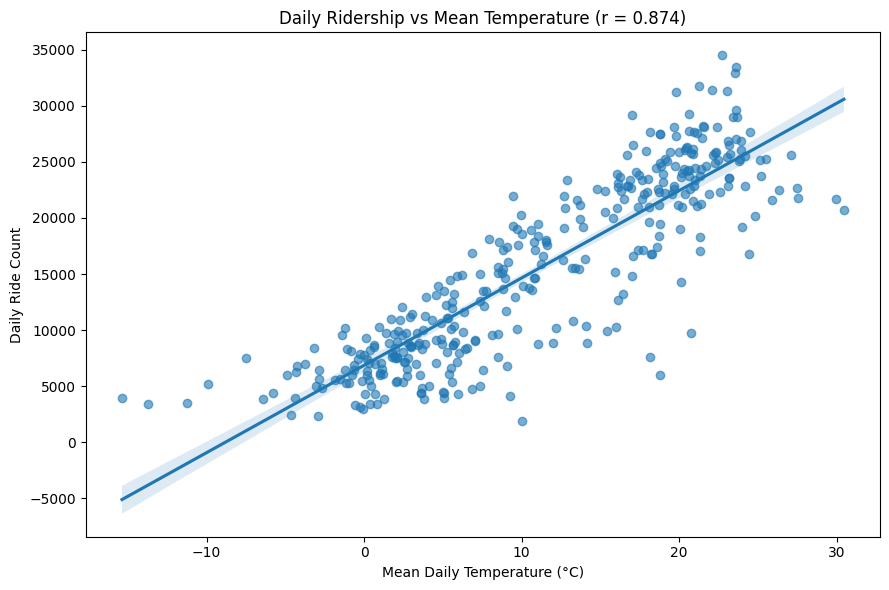

In [72]:
plt.figure(figsize=(9, 6))
sns.regplot(data=daily_df, x="temperature_mean_c", y="ride_count", scatter_kws={"alpha": 0.6})

plt.title(f"Daily Ridership vs Mean Temperature (r = {temp_corr:.3f})")
plt.xlabel("Mean Daily Temperature (°C)")
plt.ylabel("Daily Ride Count")

plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

#### Observation

- Mean daily temperature showed a strong positive correlation with total daily ridership (`r = 0.874`).
- Member rides also showed a strong positive relationship with temperature (`r = 0.834`).
- Casual rides showed a similarly strong positive relationship (`r = 0.824`).
- Higher-temperature days were therefore generally associated with substantially higher Divvy ridership during 2023.

Temperature shows one of the clearest relationships with daily ride demand identified in the analysis.

### 7.3 How Does Rain Affect Daily Ridership?

In [73]:
daily_df["rainy_day"] = daily_df["rain_mm"] > 0

In [74]:
rain_summary = (daily_df.groupby("rainy_day")[["ride_count", "member_rides", "casual_rides"]].mean().reset_index())
rain_summary["weather"] = rain_summary["rainy_day"].map({False: "Dry",True: "Rainy"})

rain_summary

,rainy_day,ride_count,member_rides,casual_rides,weather
0,False,15974.336788,10133.709845,5840.626943,Dry
1,True,14783.000000,9563.127907,5219.872093,Rainy


In [75]:
daily_df["rainy_day"].value_counts()

rainy_day
False    193
True     172
Name: count, dtype: int64

In [76]:
daily_df.groupby("rainy_day")["avg_ride_duration"].mean()

rainy_day
False    13.906909
True     13.292225
Name: avg_ride_duration, dtype: float64

#### Observation

- The dataset contained 193 dry days and 172 days with recorded rainfall.
- Dry days averaged approximately 15,974 rides, compared with 14,783 rides on rainy days.
- Average daily ridership was approximately 7.46% lower on rainy days than on dry days.

### 7.4 How Does Snowfall Affect Daily Ridership?

In [77]:
daily_df["snow_day"] = daily_df["snowfall_cm"] > 0

In [78]:
snow_summary = (daily_df.groupby("snow_day")[["ride_count", "member_rides", "casual_rides"]].mean().reset_index())
snow_summary["weather"] = snow_summary["snow_day"].map({False: "No Snow",True: "Snow"})

snow_summary

,snow_day,ride_count,member_rides,casual_rides,weather
0,False,16436.045593,10430.629179,6005.416413,No Snow
1,True,6062.888889,4694.083333,1368.805556,Snow


In [79]:
daily_df["snow_day"].value_counts()

snow_day
False    329
True      36
Name: count, dtype: int64

In [80]:
daily_df.groupby("snow_day")["avg_ride_duration"].mean()

snow_day
False    13.932691
True     10.734466
Name: avg_ride_duration, dtype: float64

#### Observation

- Snowfall was recorded on 36 days during 2023, compared with 329 days without snowfall.
- Days without snowfall averaged approximately 16,436 rides, while snow days averaged only 6,063 rides.
- Average daily ridership was approximately 63.11% lower on snow days than on days without snowfall.

Because snowfall occurs primarily during colder periods, this comparison also reflects broader seasonal and temperature differences. It should therefore be interpreted as an association rather than the isolated effect of snowfall.

### 7.5 Does Wind Speed Relate to Daily Ridership?

In [81]:
wind_corr = daily_df["wind_speed_max_kmh"].corr(daily_df["ride_count"])
member_wind_corr = daily_df["wind_speed_max_kmh"].corr(daily_df["member_rides"])
casual_wind_corr = daily_df["wind_speed_max_kmh"].corr(daily_df["casual_rides"])

print(f"All rides vs wind speed: {wind_corr:.3f}")
print(f"Member rides vs wind speed: {member_wind_corr:.3f}")
print(f"Casual rides vs wind speed: {casual_wind_corr:.3f}")

All rides vs wind speed: -0.362
Member rides vs wind speed: -0.337
Casual rides vs wind speed: -0.351


#### Observation

- Maximum daily wind speed showed a moderate negative correlation with total ridership (`r = -0.362`).
- The relationship was similar for member rides (`r = -0.337`) and casual rides (`r = -0.351`).
- Higher wind speeds were therefore generally associated with lower daily ridership, although the relationship was considerably weaker than the relationship observed with temperature.

Wind speed shows a noticeable but comparatively modest relationship with daily demand.

### 7.6 Do Member and Casual Rides Respond Differently to Weather?

In [82]:
dry_days = rain_summary[rain_summary["weather"] == "Dry"].iloc[0]
rainy_days = rain_summary[rain_summary["weather"] == "Rainy"].iloc[0]

In [83]:
member_rain_change = (
    (rainy_days["member_rides"] - dry_days["member_rides"])
    / dry_days["member_rides"]
    * 100
)

casual_rain_change = (
    (rainy_days["casual_rides"] - dry_days["casual_rides"])
    / dry_days["casual_rides"]
    * 100
)

print(
    f"Member ride change on rainy days: "
    f"{member_rain_change:.2f}%"
)

print(
    f"Casual ride change on rainy days: "
    f"{casual_rain_change:.2f}%"
)

Member ride change on rainy days: -5.63%
Casual ride change on rainy days: -10.63%


In [84]:
no_snow_days = snow_summary[
    snow_summary["weather"] == "No Snow"
].iloc[0]

snow_days = snow_summary[
    snow_summary["weather"] == "Snow"
].iloc[0]

In [85]:
member_snow_change = (
    (snow_days["member_rides"] - no_snow_days["member_rides"])
    / no_snow_days["member_rides"]
    * 100
)

casual_snow_change = (
    (snow_days["casual_rides"] - no_snow_days["casual_rides"])
    / no_snow_days["casual_rides"]
    * 100
)

print(
    f"Member ride change on snow days: "
    f"{member_snow_change:.2f}%"
)

print(
    f"Casual ride change on snow days: "
    f"{casual_snow_change:.2f}%"
)

Member ride change on snow days: -55.00%
Casual ride change on snow days: -77.21%


In [86]:
weather_impact = pd.DataFrame({
    "weather_condition": ["Rain", "Snow"],
    "member_change": [
        member_rain_change,
        member_snow_change
    ],
    "casual_change": [
        casual_rain_change,
        casual_snow_change
    ]
})

weather_impact

,weather_condition,member_change,casual_change
0,Rain,-5.630534,-10.628223
1,Snow,-54.997122,-77.207150


In [87]:
weather_impact_long = weather_impact.melt(
    id_vars="weather_condition",
    value_vars=[
        "member_change",
        "casual_change"
    ],
    var_name="membership_type",
    value_name="percentage_change"
)

weather_impact_long["membership_type"] = (
    weather_impact_long["membership_type"]
    .replace({
        "member_change": "Member",
        "casual_change": "Casual"
    })
)

weather_impact_long

,weather_condition,membership_type,percentage_change
0,Rain,Member,-5.630534
1,Snow,Member,-54.997122
2,Rain,Casual,-10.628223
3,Snow,Casual,-77.207150


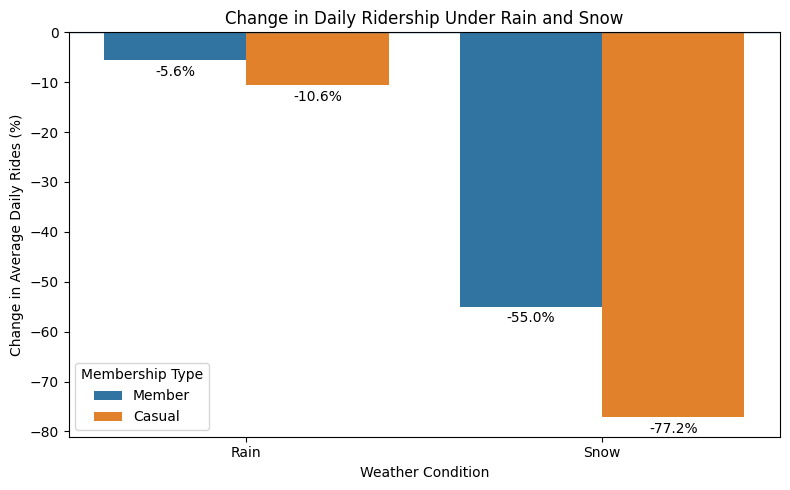

In [88]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=weather_impact_long,
    x="weather_condition",
    y="percentage_change",
    hue="membership_type"
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Change in Daily Ridership Under Rain and Snow")
plt.xlabel("Weather Condition")
plt.ylabel("Change in Average Daily Rides (%)")

plt.legend(title="Membership Type")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()


#### Observation

- Member and casual rides both declined under rainy and snowy conditions, but the differences were larger for casual rides.
- On rainy days, member rides were 5.63% lower than on dry days, while casual rides were 10.63% lower.
- On snow days, member rides were 55.00% lower than on days without snowfall, while casual rides were 77.21% lower.
- Temperature was strongly associated with both groups, with correlations of `0.834` for member rides and `0.824` for casual rides.
- The temperature correlations themselves were very similar, but the rain and snow comparisons show larger changes among casual rides.

Overall, casual ridership appears more sensitive to adverse precipitation conditions, while member ridership remains comparatively more stable.

### 7.7 Weather and Ridership Analysis Summary

Weather conditions showed clear relationships with daily Divvy ridership.

Key findings include:

- Mean daily temperature had a strong positive relationship with total ridership (`r = 0.874`), making it the clearest weather-related pattern in the analysis.
- Rainy days averaged approximately 7.5% fewer rides than dry days, with a larger difference among casual rides.
- Snow days had substantially lower ridership than days without snowfall. Member rides were 55.00% lower, while casual rides were 77.21% lower.
- Higher wind speeds were moderately associated with lower ridership (`r = -0.362`).
- Member and casual rides responded similarly to temperature, but casual ridership showed larger differences under rainy and snowy conditions.

Overall, temperature showed the strongest relationship with daily ride demand, while the rain and snow comparisons suggest that casual ridership is more sensitive to adverse weather conditions.

### Memory Cleanup

Intermediate DataFrames and Series created in the previous analyses are removed to reduce memory usage before the station and route analysis. The main `df` DataFrame is retained.

In [89]:
import gc
import pandas as pd
import matplotlib.pyplot as plt

for variable_name, variable_value in list(globals().items()):
    
    if variable_name == "df":
        continue
    
    if isinstance(variable_value, (pd.DataFrame, pd.Series)):
        del globals()[variable_name]

plt.close("all")
gc.collect()

13379

In [90]:
[
    name
    for name, value in globals().items()
    if isinstance(value, (pd.DataFrame, pd.Series))
]

['df', '__', '___']

## 8. Station and Route Analysis

- This section examines where Divvy trips begin and end, which routes are used most frequently, and whether station usage differs between member and casual rides.

- Because some trips have missing station information, each analysis uses only the rides for which the required station fields are available.

- The analysis addresses the following questions:

    - Which stations have the highest number of trip departures?
    - Which stations have the highest number of trip arrivals?
    - Do member and casual rides show different starting-station preferences?
    - Which station-to-station routes are used most frequently?
    - How common are trips that start and end at the same station?
    - Which stations show the largest difference between arrivals and departures?

### 8.1 Station Data Coverage
- Before analyzing stations, let's quantify how much of the dataset is actually usable.

In [91]:
start_station_available = df["start_station_name"].notna().sum()
end_station_available = df["end_station_name"].notna().sum()

both_stations_available = (df["start_station_name"].notna() & df["end_station_name"].notna()).sum()

print(f"Trips with start station information: {start_station_available:,} ({start_station_available / len(df) * 100:.2f}%)")
print(f"Trips with end station information: {end_station_available:,} ({end_station_available / len(df) * 100:.2f}%)")
print(f"Trips with both stations available: {both_stations_available:,} ({both_stations_available / len(df) * 100:.2f}%)")

Trips with start station information: 4,750,406 (84.44%)
Trips with end station information: 4,703,681 (83.61%)
Trips with both stations available: 4,245,180 (75.46%)


#### Observation

- Start-station information was available for 84.44% of rides, while end-station information was available for 83.61%.
- Both start and end stations were available for 75.46% of all rides.
- Route-based analysis therefore covers approximately three quarters of the complete dataset.

The station and route results should be interpreted within this subset of rides because trips with missing station information are excluded.

### 8.2 Which Stations Have the Highest Number of Trip Departures?

In [92]:
top_start_stations = df["start_station_name"].value_counts().head(10).reset_index()
top_start_stations.columns = ["start_station_name", "ride_count"]
top_start_stations

,start_station_name,ride_count
0,Streeter Dr & Grand Ave,61832
1,DuSable Lake Shore Dr & Monroe St,39358
2,Michigan Ave & Oak St,36597
3,DuSable Lake Shore Dr & North Blvd,35300
4,Clark St & Elm St,35199
5,Kingsbury St & Kinzie St,34375
6,Wells St & Concord Ln,33027
7,Clinton St & Washington Blvd,32086
8,Wells St & Elm St,29946
9,Theater on the Lake,29505


### 8.3 Which Stations Have the Highest Number of Trip Arrivals?

In [93]:
top_end_stations = df["end_station_name"].value_counts().head(10).reset_index()
top_end_stations.columns = ["end_station_name", "ride_count"]
top_end_stations

,end_station_name,ride_count
0,Streeter Dr & Grand Ave,62992
1,DuSable Lake Shore Dr & North Blvd,38688
2,Michigan Ave & Oak St,37295
3,DuSable Lake Shore Dr & Monroe St,37266
4,Clark St & Elm St,34381
5,Kingsbury St & Kinzie St,33700
6,Wells St & Concord Ln,33639
7,Clinton St & Washington Blvd,32795
8,Millennium Park,30422
9,Theater on the Lake,30098


#### Observation

- Streeter Dr & Grand Ave was the busiest station for both departures and arrivals, with 61,832 departures and 62,992 arrivals.
- Nine of the ten busiest departure stations also appeared among the ten busiest arrival stations.
- Several lakefront and central Chicago stations appeared consistently near the top of both rankings.

The strong overlap suggests that the highest-activity stations generally function as major origins and destinations rather than being dominated by only one direction of travel.

### 8.4 Member vs Casual Starting Stations

In [94]:
top_member_start_stations = df.loc[df["member_casual"] == "member","start_station_name"].value_counts().head(10).reset_index()
top_member_start_stations.columns = ["start_station_name", "ride_count"]
top_member_start_stations

,start_station_name,ride_count
0,Kingsbury St & Kinzie St,25711
1,Clinton St & Washington Blvd,25686
2,Clark St & Elm St,24552
3,Wells St & Concord Ln,21032
4,Clinton St & Madison St,20225
5,Wells St & Elm St,20084
6,University Ave & 57th St,19627
7,Broadway & Barry Ave,18635
8,Loomis St & Lexington St,18439
9,State St & Chicago Ave,18152


In [95]:
top_casual_start_stations = df.loc[df["member_casual"] == "casual","start_station_name"].value_counts().head(10).reset_index()
top_casual_start_stations.columns = ["start_station_name", "ride_count"]
top_casual_start_stations

,start_station_name,ride_count
0,Streeter Dr & Grand Ave,44991
1,DuSable Lake Shore Dr & Monroe St,29811
2,Michigan Ave & Oak St,22207
3,DuSable Lake Shore Dr & North Blvd,20006
4,Millennium Park,19693
5,Shedd Aquarium,17401
6,Theater on the Lake,16051
7,Dusable Harbor,15133
8,Wells St & Concord Ln,11995
9,Montrose Harbor,11736


In [96]:
member_top_names = set(top_member_start_stations["start_station_name"])
casual_top_names = set(top_casual_start_stations["start_station_name"])

common_top_stations = member_top_names.intersection(casual_top_names)

print(f"Stations appearing in both top-10 lists: {len(common_top_stations)}")

common_top_stations

Stations appearing in both top-10 lists: 1


{'Wells St & Concord Ln'}

In [97]:
member_stations_plot = top_member_start_stations.copy()
member_stations_plot["membership_type"] = "Member"

casual_stations_plot = top_casual_start_stations.copy()
casual_stations_plot["membership_type"] = "Casual"

station_membership_plot = pd.concat([member_stations_plot, casual_stations_plot], ignore_index=True)
station_membership_plot

,start_station_name,ride_count,membership_type
0,Kingsbury St & Kinzie St,25711,Member
1,Clinton St & Washington Blvd,25686,Member
2,Clark St & Elm St,24552,Member
3,Wells St & Concord Ln,21032,Member
4,Clinton St & Madison St,20225,Member
5,Wells St & Elm St,20084,Member
6,University Ave & 57th St,19627,Member
7,Broadway & Barry Ave,18635,Member
8,Loomis St & Lexington St,18439,Member
9,State St & Chicago Ave,18152,Member


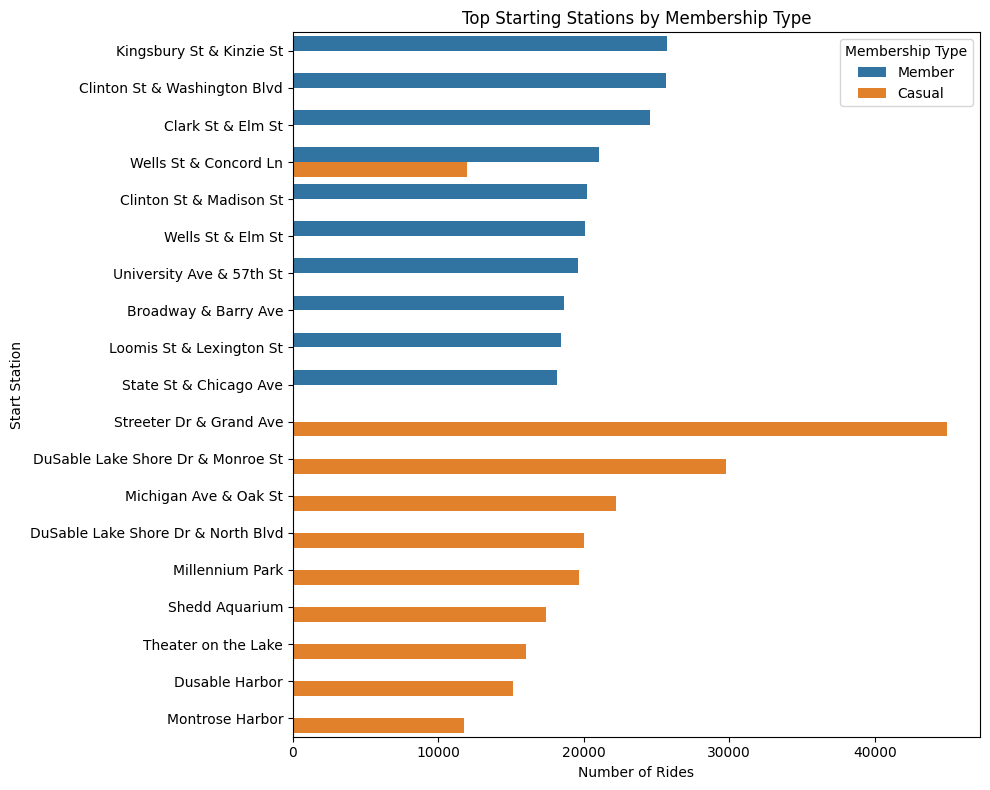

In [98]:
plt.figure(figsize=(10, 8))

sns.barplot(data=station_membership_plot,
            y="start_station_name",
            x="ride_count",
            hue="membership_type")

plt.title("Top Starting Stations by Membership Type")
plt.xlabel("Number of Rides")
plt.ylabel("Start Station")
plt.legend(title="Membership Type")

plt.ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()

#### Observation

- Member and casual rides showed substantially different starting-station patterns.
- Only one station, Wells St & Concord Ln, appeared in both groups' top-ten starting-station lists.
- Streeter Dr & Grand Ave was the most common starting station for casual rides, with 44,991 rides.
- Kingsbury St & Kinzie St was the most common starting station for member rides, with 25,711 rides.
- Several of the most common casual starting stations were located around the lakefront and major visitor destinations, including Millennium Park, Shedd Aquarium, Theater on the Lake, and Dusable Harbor.

The very limited overlap between the two rankings indicates a substantial difference in where member and casual trips most frequently begin.

### 8.5 Most Frequently Used Routes

In [99]:
df["routes"] = df["start_station_name"] + " → " + df["end_station_name"]

In [100]:
top_routes = df[df["start_station_name"].notna() &
                 df["end_station_name"].notna() & 
                 (df["start_station_name"] != df["end_station_name"])]["routes"].value_counts().head(10).reset_index(name = "ride_count")
top_routes

,routes,ride_count
0,Ellis Ave & 60th St → Ellis Ave & 55th St,6964
1,Ellis Ave & 60th St → University Ave & 57th St,6671
2,Ellis Ave & 55th St → Ellis Ave & 60th St,6401
3,University Ave & 57th St → Ellis Ave & 60th St,6250
4,Calumet Ave & 33rd St → State St & 33rd St,5473
5,State St & 33rd St → Calumet Ave & 33rd St,5374
6,DuSable Lake Shore Dr & Monroe St → Streeter D...,5130
7,Loomis St & Lexington St → Morgan St & Polk St,3748
8,Morgan St & Polk St → Loomis St & Lexington St,3400
9,University Ave & 57th St → Kimbark Ave & 53rd St,3159


In [101]:
top_routes_member = df[df["start_station_name"].notna() &
                        df["end_station_name"].notna() & 
                        (df["start_station_name"] != df["end_station_name"]) & 
                        (df["member_casual"] == "member")]["routes"].value_counts().head(10).reset_index(name = "ride_count")
top_routes_member

,routes,ride_count
0,Ellis Ave & 60th St → University Ave & 57th St,5208
1,Calumet Ave & 33rd St → State St & 33rd St,5201
2,State St & 33rd St → Calumet Ave & 33rd St,5145
3,University Ave & 57th St → Ellis Ave & 60th St,4935
4,Ellis Ave & 60th St → Ellis Ave & 55th St,4927
5,Ellis Ave & 55th St → Ellis Ave & 60th St,4524
6,Loomis St & Lexington St → Morgan St & Polk St,3444
7,Morgan St & Polk St → Loomis St & Lexington St,3163
8,MLK Jr Dr & 29th St → State St & 33rd St,2528
9,State St & 33rd St → MLK Jr Dr & 29th St,2447


In [102]:
top_routes_casual = df[df["start_station_name"].notna() &
                        df["end_station_name"].notna() & 
                        (df["start_station_name"] != df["end_station_name"]) & 
                        (df["member_casual"] == "casual")]["routes"].value_counts().head(10).reset_index(name = "ride_count")
top_routes_casual

,routes,ride_count
0,DuSable Lake Shore Dr & Monroe St → Streeter D...,4621
1,Streeter Dr & Grand Ave → DuSable Lake Shore D...,2350
2,Ellis Ave & 60th St → Ellis Ave & 55th St,2037
3,Shedd Aquarium → Streeter Dr & Grand Ave,2024
4,Dusable Harbor → Streeter Dr & Grand Ave,1996
5,Streeter Dr & Grand Ave → Michigan Ave & Oak St,1945
6,Streeter Dr & Grand Ave → Millennium Park,1930
7,Ellis Ave & 55th St → Ellis Ave & 60th St,1877
8,Streeter Dr & Grand Ave → DuSable Lake Shore D...,1740
9,Shedd Aquarium → DuSable Lake Shore Dr & Monro...,1731


#### Observation

- The most frequently used routes differed noticeably between member and casual rides.
- Among member rides, the top routes were concentrated around stations such as Ellis Ave, University Ave, Calumet Ave, State St, Loomis St, and Morgan St.
- Among casual rides, the most common routes were more concentrated around Streeter Dr & Grand Ave, DuSable Lake Shore Dr, Shedd Aquarium, Dusable Harbor, Michigan Ave & Oak St, and Millennium Park.
- Several of the overall top routes also appeared in both directions, indicating strong two-way movement between the same station pairs.

These results reinforce the earlier station-level finding that member and casual rides tend to concentrate in different parts of the network and use different high-frequency routes.

### 8.6 Same-Station Trips

In [103]:
same_station_rides = df[(df["start_station_name"] == df["end_station_name"]) &
    (df["start_station_name"].notna())]["start_station_name"].value_counts().head(10).reset_index(name = "ride_count")
same_station_rides.columns = ["same_station_name", "ride_count"]
same_station_rides

,same_station_name,ride_count
0,Streeter Dr & Grand Ave,8915
1,DuSable Lake Shore Dr & Monroe St,6825
2,Michigan Ave & Oak St,4563
3,Millennium Park,3255
4,Montrose Harbor,2963
5,Dusable Harbor,2912
6,DuSable Lake Shore Dr & North Blvd,2209
7,Theater on the Lake,2186
8,Adler Planetarium,2150
9,Shedd Aquarium,1916


In [104]:
same_station_rides_member = df[(df["start_station_name"] == df["end_station_name"]) &
                        (df["start_station_name"].notna()) & 
                        (df["member_casual"] == "member")]["start_station_name"].value_counts().head(10).reset_index(name = "ride_count")
same_station_rides_member.columns = ["same_station_name", "ride_count"]
same_station_rides_member

,same_station_name,ride_count
0,Streeter Dr & Grand Ave,1024
1,Loomis St & Lexington St,849
2,MLK Jr Dr & 29th St,771
3,Michigan Ave & Oak St,672
4,Montrose Harbor,641
5,State St & 33rd St,600
6,Broadway & Barry Ave,593
7,DuSable Lake Shore Dr & Monroe St,593
8,Morgan St & Polk St,523
9,DuSable Lake Shore Dr & Wellington Ave,515


In [105]:
same_station_rides_casual = df[(df["start_station_name"] == df["end_station_name"]) &
                        (df["start_station_name"].notna()) & 
                        (df["member_casual"] == "casual")]["start_station_name"].value_counts().head(10).reset_index(name = "ride_count")
same_station_rides_casual.columns = ["same_station_name", "ride_count"]
same_station_rides_casual

,same_station_name,ride_count
0,Streeter Dr & Grand Ave,7891
1,DuSable Lake Shore Dr & Monroe St,6232
2,Michigan Ave & Oak St,3891
3,Millennium Park,3052
4,Dusable Harbor,2543
5,Montrose Harbor,2322
6,Adler Planetarium,1777
7,DuSable Lake Shore Dr & North Blvd,1774
8,Shedd Aquarium,1741
9,Theater on the Lake,1678


In [106]:
same_stations_trip_overall = len(df[(df["start_station_name"].notna()) & 
                                    (df["start_station_name"] == df["end_station_name"])])

same_stations_trip_member = len(df[(df["start_station_name"].notna()) & 
                                   (df["start_station_name"] == df["end_station_name"]) &
                                   (df["member_casual"] == "member")])

same_stations_trip_casual= len(df[(df["start_station_name"].notna()) & 
                                   (df["start_station_name"] == df["end_station_name"]) &
                                   (df["member_casual"] == "casual")])

In [107]:
valid_station_trips = ((df["start_station_name"].notna())& 
                       (df["end_station_name"].notna())).sum()

valid_station_trips_member = ((df["start_station_name"].notna()) & 
                              (df["end_station_name"].notna()) & 
                              (df["member_casual"] == "member")).sum()

valid_station_trips_casual = ((df["start_station_name"].notna()) & 
                              (df["end_station_name"].notna()) & 
                              (df["member_casual"] == "casual")).sum()

In [108]:
same_station_percentage_overall = (same_stations_trip_overall / valid_station_trips) * 100
same_station_percentage_member = (same_stations_trip_member / valid_station_trips_member) * 100
same_station_percentage_casual = (same_stations_trip_casual / valid_station_trips_casual) * 100

In [109]:
print(f"Overall same-station trips: {same_stations_trip_overall:,} ({same_station_percentage_overall:.2f}%)")
print(f"Member same-station trips: {same_stations_trip_member:,} ({same_station_percentage_member:.2f}%)")
print(f"Casual same-station trips: {same_stations_trip_casual:,} ({same_station_percentage_casual:.2f}%)")

Overall same-station trips: 191,246 (4.51%)
Member same-station trips: 69,069 (2.52%)
Casual same-station trips: 122,177 (8.13%)


#### Observation

- Same-station trips represented 4.51% of all trips with both start and end station information available.
- Among member rides, only 2.52% started and ended at the same station.
- Among casual rides, this proportion increased to 8.13%, more than three times the member rate.
- Casual same-station trips were particularly concentrated at locations such as Streeter Dr & Grand Ave, DuSable Lake Shore Dr & Monroe St, Michigan Ave & Oak St, Millennium Park, Dusable Harbor, and Shedd Aquarium.
- Member same-station trips were less concentrated around these locations and showed a more mixed station pattern.

Same-station trips therefore represent a much more prominent pattern among casual rides than among member rides, reinforcing the broader differences observed between the two membership groups.

In [110]:
same_station_plot = pd.DataFrame({"membership_type": ["Member", "Casual"], 
                                  "percentage": [same_station_percentage_member, same_station_percentage_casual]})

same_station_plot

,membership_type,percentage
0,Member,2.519292
1,Casual,8.125762


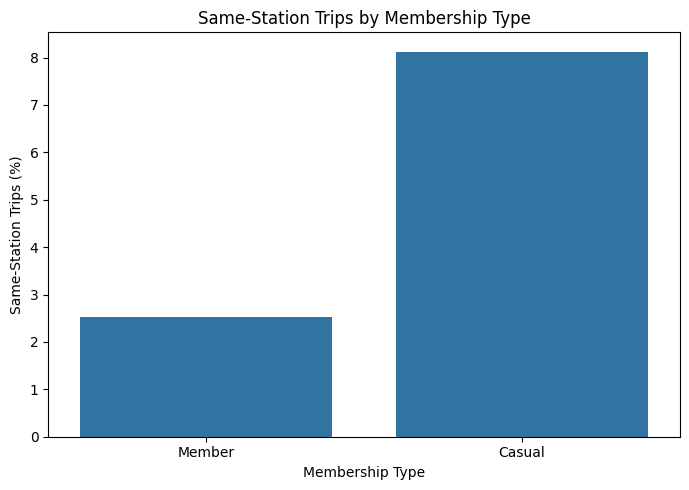

In [111]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(data=same_station_plot, 
                 x="membership_type", 
                 y="percentage")

plt.title("Same-Station Trips by Membership Type")
plt.xlabel("Membership Type")
plt.ylabel("Same-Station Trips (%)")

plt.tight_layout()
plt.show()

### 8.7 Which Stations Show the Largest Difference Between Arrivals and Departures?

In [112]:
station_departures = df["start_station_name"].value_counts().reset_index()
station_departures.columns = ["station_name", "departures"]

station_arrivals = df["end_station_name"].value_counts().reset_index()
station_arrivals.columns = ["station_name", "arrivals"]

station_flow = station_departures.merge(station_arrivals,on="station_name",how="outer")

station_flow = station_flow.fillna(0)
station_flow.head()

,station_name,departures,arrivals
0,2112 W Peterson Ave,722.0,772.0
1,410,7.0,1.0
2,63rd St Beach,962.0,951.0
3,900 W Harrison St,12487.0,11179.0
4,Aberdeen St & Jackson Blvd,14675.0,13230.0


In [113]:
station_flow["net_flow"] = station_flow["arrivals"] - station_flow["departures"]
station_flow["absolute_imbalance"] = (station_flow["net_flow"].abs())
station_flow.head()

,station_name,departures,arrivals,net_flow,absolute_imbalance
0,2112 W Peterson Ave,722.0,772.0,50.0,50.0
1,410,7.0,1.0,-6.0,6.0
2,63rd St Beach,962.0,951.0,-11.0,11.0
3,900 W Harrison St,12487.0,11179.0,-1308.0,1308.0
4,Aberdeen St & Jackson Blvd,14675.0,13230.0,-1445.0,1445.0


In [114]:
largest_station_imbalances = station_flow.sort_values("absolute_imbalance",ascending=False).head(10)

largest_station_imbalances

,station_name,departures,arrivals,net_flow,absolute_imbalance
199,Columbus Dr & Randolph St,20109.0,16617.0,-3492.0,3492.0
253,Desplaines St & Kinzie St,22885.0,19492.0,-3393.0,3393.0
267,DuSable Lake Shore Dr & North Blvd,35300.0,38688.0,3388.0,3388.0
1420,Sheffield Ave & Waveland Ave,19843.0,22788.0,2945.0,2945.0
326,Green St & Randolph St*,5782.0,8670.0,2888.0,2888.0
1410,Sedgwick St & Huron St,14688.0,11881.0,-2807.0,2807.0
1556,Wells St & Walton St,11775.0,9223.0,-2552.0,2552.0
307,Financial Pl & Ida B Wells Dr,10393.0,8074.0,-2319.0,2319.0
306,Field Museum,10422.0,8150.0,-2272.0,2272.0
565,Michigan Ave & 8th St,17248.0,15114.0,-2134.0,2134.0


In [115]:
top_positive_flow = station_flow.sort_values("net_flow", ascending=False).head(10)
top_positive_flow

,station_name,departures,arrivals,net_flow,absolute_imbalance
267,DuSable Lake Shore Dr & North Blvd,35300.0,38688.0,3388.0,3388.0
1420,Sheffield Ave & Waveland Ave,19843.0,22788.0,2945.0,2945.0
326,Green St & Randolph St*,5782.0,8670.0,2888.0,2888.0
1405,Sangamon St & Lake St,12148.0,14087.0,1939.0,1939.0
510,Lincoln Ave & Roscoe St*,6608.0,8035.0,1427.0,1427.0
236,Damen Ave & Pierce Ave,19841.0,21221.0,1380.0,1380.0
1496,Streeter Dr & Grand Ave,61832.0,62992.0,1160.0,1160.0
1605,Wood St & Milwaukee Ave,13306.0,14463.0,1157.0,1157.0
191,Clinton St & Madison St,26369.0,27490.0,1121.0,1121.0
1446,Southport Ave & Clybourn Ave,8629.0,9734.0,1105.0,1105.0


In [116]:
top_negative_flow = station_flow.sort_values("net_flow", ascending=True).head(10)
top_negative_flow

,station_name,departures,arrivals,net_flow,absolute_imbalance
199,Columbus Dr & Randolph St,20109.0,16617.0,-3492.0,3492.0
253,Desplaines St & Kinzie St,22885.0,19492.0,-3393.0,3393.0
1410,Sedgwick St & Huron St,14688.0,11881.0,-2807.0,2807.0
1556,Wells St & Walton St,11775.0,9223.0,-2552.0,2552.0
307,Financial Pl & Ida B Wells Dr,10393.0,8074.0,-2319.0,2319.0
306,Field Museum,10422.0,8150.0,-2272.0,2272.0
565,Michigan Ave & 8th St,17248.0,15114.0,-2134.0,2134.0
266,DuSable Lake Shore Dr & Monroe St,39358.0,37266.0,-2092.0,2092.0
9,Adler Planetarium,16562.0,14651.0,-1911.0,1911.0
1478,State St & Pearson St,9226.0,7690.0,-1536.0,1536.0


#### Observation

- Several stations showed noticeable differences between the number of recorded departures and arrivals.
- Columbus Dr & Randolph St had the largest absolute imbalance, with 3,492 more departures than arrivals.
- Desplaines St & Kinzie St showed a similar pattern, with 3,393 more departures than arrivals.
- In the opposite direction, DuSable Lake Shore Dr & North Blvd recorded 3,388 more arrivals than departures, the largest positive net flow.
- Sheffield Ave & Waveland Ave and Green St & Randolph St also received substantially more rides than they generated.
- Some very high-activity stations, such as Streeter Dr & Grand Ave, showed a much smaller difference between arrivals and departures despite handling a large number of trips.

These results indicate that some stations experience considerably more directional flow than others. However, the data does not include station capacity, bike availability, or actual rebalancing activity, so these differences should not be interpreted as direct evidence of rebalancing requirements.

### 8.8 Station and Route Analysis Summary

Station and route usage revealed substantial differences in how member and casual rides were distributed across the Divvy network.

Key findings include:

- Both start and end station information was available for 75.46% of all rides, providing more than 4.2 million trips for route-based analysis.
- Streeter Dr & Grand Ave was the busiest station for both departures and arrivals, with 61,832 departures and 62,992 arrivals.
- Nine of the ten busiest departure stations also appeared among the ten busiest arrival stations, indicating that the highest-activity stations generally serve as both major origins and destinations.
- Member and casual rides showed very different starting-station patterns. Only Wells St & Concord Ln appeared in both groups' top-ten starting-station lists.
- The most frequently used routes also differed noticeably between member and casual rides, reinforcing the differences observed at the station level.
- Same-station trips represented 4.51% of trips with valid station information. However, they accounted for 8.13% of casual rides compared with only 2.52% of member rides.
- Casual same-station trips were particularly concentrated around locations such as Streeter Dr & Grand Ave, DuSable Lake Shore Dr & Monroe St, Millennium Park, Dusable Harbor, and Shedd Aquarium.
- Several stations also showed substantial differences between arrivals and departures. Columbus Dr & Randolph St recorded 3,492 more departures than arrivals, while DuSable Lake Shore Dr & North Blvd recorded 3,388 more arrivals than departures.

Overall, the station and route analysis shows that member and casual rides differ substantially in where trips begin, which routes are most frequently used, and how often trips return to their starting station. The station-flow results also show that high activity and directional imbalance are distinct characteristics of station usage.

## 9. Key Findings and Conclusion

The exploratory analysis of Divvy bike-share activity in 2023 revealed several clear patterns in when, how, and where the system was used.

### Key Findings

- Divvy recorded more than 5.6 million rides during 2023, with member rides representing approximately 64% of total activity.
- Ridership showed strong seasonality, with summer accounting for the largest share of rides and winter the smallest.
- Weekday usage showed pronounced morning and evening peaks, while weekend demand was more broadly distributed throughout the daytime.
- Member and casual rides displayed different usage patterns. Members were more concentrated around weekday and peak-hour travel, while casual rides showed stronger weekend and seasonal concentration and longer average ride durations.
- Bike-type usage was relatively balanced overall, but classic-bike rides lasted longer than electric-bike rides, particularly among casual rides.
- Weather was strongly associated with daily ridership. Mean daily temperature showed a strong positive correlation with ride demand (`r = 0.874`), while rainy, snowy, and windier conditions were associated with lower ridership.
- Casual ridership showed larger differences under adverse precipitation conditions than member ridership. Casual rides were 10.63% lower on rainy days and 77.21% lower on snow days compared with their respective reference conditions.
- Member and casual rides also differed substantially in their use of the station network. Only one station appeared in both groups' top-ten starting-station lists.
- Same-station trips were considerably more common among casual rides, representing 8.13% of valid casual trips compared with 2.52% of member trips.
- Station-flow analysis showed that high station activity and directional imbalance are separate characteristics, with some stations recording substantially more arrivals than departures or vice versa.

### Conclusion

Overall, the analysis shows that Divvy usage varies considerably by time, membership type, weather conditions, and location. Member rides generally follow more regular weekday and peak-hour patterns, while casual rides show stronger seasonal, weekend, and same-station usage patterns.

These findings provide the exploratory foundation for the next stage of the project, where daily Divvy ride demand will be modeled using temporal and weather-related features.